# Sales 2025 SKU Real vs Edit Visualization

Notebook ini fokus ke satu tujuan: melihat dampak penyamaan SKU terhadap trend `CF` di `Sales 2025`.

Rule alignment:
- BIG 1625 / 1.625L -> BIG 1L terbaru
- BIG 3100 / 3.1L -> BIG 3L terbaru
- BIG 400ml dengan flavour sama -> SKU 400ml terbaru
- BIG Nipis 350ml -> deskripsi terbaru, SKU tetap sama
- VOLT 200ml -> SKU/deskripsi 24-pack terbaru
- Jika SKU 12-pack diarahkan ke 24-pack, `CF Edit = CF Real / 2`

In [185]:
# ==========================================
# 1. SALES 2025 SKU REAL VS EDIT VISUALIZATION
# ==========================================
# Memuat library utama dan menyiapkan opsi tampilan dataframe/chart.

# Mengimpor modul bawaan Python untuk manipulasi path, regex, dan file zip.
from pathlib import Path
import re
import zipfile

# Mengimpor library utama untuk komputasi numerik (NumPy) dan manipulasi data (Pandas).
import numpy as np
import pandas as pd

# Mencoba mengimpor Plotly untuk visualisasi interaktif.
try:
    import plotly.express as px
except ModuleNotFoundError:
    # Mengabaikan error jika Plotly tidak terinstal.
    px = None

# Mencoba mengimpor Matplotlib untuk visualisasi statis dan pemformatan sumbu (axis).
try:
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
except ModuleNotFoundError:
    plt = None
    FuncFormatter = None

# Mengatur tampilan Pandas agar dapat menampilkan hingga 120 kolom dan memperlebar tampilan tabel.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

## 1. Source File

Notebook ini hanya memakai file dari Google Drive. Ubah path di bawah kalau lokasi file di Drive berbeda.

In [186]:
# ==========================================
# 2. 1. SOURCE FILE
# ==========================================
# Menentukan lokasi file dashboard di Google Drive dan memastikan file Excel dapat dibaca.

# Mendefinisikan lokasi absolut file di Google Drive.
DRIVE_SALES_FILE = Path("/content/drive/MyDrive/Data Sales/Indonesia Sales Dashboard 2026.xlsm")

try:
    from google.colab import drive
    # Menghubungkan (mount) Google Drive ke Colab.
    drive.mount("/content/drive")
except ModuleNotFoundError:
    # Mengabaikan error jika dijalankan di luar Colab, dan menampilkan peringatan.
    print("Run this notebook in Colab, or mount Google Drive manually before running.")

# Menghentikan program dengan error jika file tidak ditemukan.
if not DRIVE_SALES_FILE.exists():
    raise FileNotFoundError(f"File not found: {DRIVE_SALES_FILE}")

# Membaca file Excel sebagai arsip ZIP untuk memvalidasi isinya.
with zipfile.ZipFile(DRIVE_SALES_FILE) as zf:
    # Memastikan file tersebut adalah dokumen Office yang valid (bukan file rusak/corrupt).
    if "[Content_Types].xml" not in zf.namelist():
        raise ValueError(f"Not a readable Excel workbook: {DRIVE_SALES_FILE}")

# Menetapkan file untuk digunakan dan menampilkan konfirmasi.
SALES_FILE = DRIVE_SALES_FILE
print("Using:", SALES_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: /content/drive/MyDrive/Data Sales/Indonesia Sales Dashboard 2026.xlsm


## 2. Load Data

Chart hanya memakai `Sales 2025`. `Sales 2026` dipakai sebagai acuan SKU terbaru.

In [187]:
# ==========================================
# 3. 2. LOAD DATA
# ==========================================
# Membaca sheet Sales 2025 sebagai data utama dan Sales 2026 sebagai acuan SKU terbaru.

sales25 = pd.read_excel(SALES_FILE, sheet_name="Sales 2025", engine="openpyxl")
sales26 = pd.read_excel(SALES_FILE, sheet_name="Sales 2026", engine="openpyxl")

print("Sales 2025:", sales25.shape)
print("Sales 2026 reference:", sales26.shape)
display(sales25.head(3))

Sales 2025: (20354, 36)
Sales 2026 reference: (18561, 37)


,ROW 2,Year,Month,Day,Channel Group,Branch,Channel,Region,Cust Code,Customer Name,District,Brand,Format,Flavor,Short Item Description (Edit),Item Code (Edited),Box Content,ID Sales,CU,CF,imp_paquetevta,imp_dscto,imp_cobrarvta,imp_impuesto2,imp_netovta,Date,Month2,Channel Group2,Distribution Point,Region_Cust Group,Trading Terms,Net Sales (Adjusted),List Expense,Column1,Item Code (Real),Short Item Description (Edit).1
0,1.0,2025,January,2,CEDIS,FACTORY,RETAIL,GREATER JAKARTA,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BEKASI,BIG,1.625,LIME,BIG LIME NRP 1Lt x6,523884,6,NaN,1.625,5,328500.0,0.0,328500.0,32554.054,295945.946,2025-01-02,1,FACTORY SALES,FACTORY,FACTORY SALES,0.0,295945.946,NaN,FXC,523417,BIG LIME NRP 1625 ML 6
1,2.0,2025,January,2,CEDIS,FACTORY,RETAIL,GREATER JAKARTA,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,JAKARTA TIMUR,BIG,1.625,LIME,BIG LIME NRP 1Lt x6,523884,6,NaN,1.950,6,394200.0,0.0,394200.0,39064.865,355135.135,2025-01-02,1,FACTORY SALES,FACTORY,FACTORY SALES,0.0,355135.135,NaN,FXC,523417,BIG LIME NRP 1625 ML 6
2,3.0,2025,January,2,CEDIS,FACTORY,RETAIL,GREATER JAKARTA,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,JAKARTA TIMUR,BIG,1.625,LIME,BIG LIME NRP 1Lt x6,523884,6,NaN,1.300,4,262800.0,0.0,262800.0,26043.243,236756.757,2025-01-02,1,FACTORY SALES,FACTORY,FACTORY SALES,0.0,236756.757,NaN,FXC,523417,BIG LIME NRP 1625 ML 6


## 3. Clean Real SKU

In [188]:
# ==========================================
# 4. 3. CLEAN REAL SKU
# ==========================================
# Membersihkan kolom SKU real, format, flavor, dan membuat Group Key untuk proses alignment.

def clean_text(value):
    if pd.isna(value):
        return ""
    value = str(value).strip().upper()
    return re.sub(r"\s+", " ", value)


def clean_code(value):
    if pd.isna(value):
        return ""
    value = str(value).strip()
    return value[:-2] if value.endswith(".0") else value


def group_key(brand, flavor, fmt):
    brand = clean_text(brand)
    flavor = clean_text(flavor)
    if pd.isna(fmt):
        return ""
    fmt = float(fmt)

    if brand == "BIG" and "NIPIS" in flavor and np.isclose(fmt, 0.35):
        return "BIG_NIPIS_350"
    if brand == "BIG" and np.isclose(fmt, 0.4):
        return "BIG_400"
    if brand == "BIG" and (np.isclose(fmt, 1.625) or np.isclose(fmt, 1.0)):
        return "BIG_1L"
    if brand == "BIG" and (np.isclose(fmt, 3.1) or np.isclose(fmt, 3.0)):
        return "BIG_3L"
    if brand == "VOLT" and np.isclose(fmt, 0.2):
        return "VOLT_200_24"
    return ""


actual = pd.DataFrame({
    "Date": pd.to_datetime(sales25["Date"], errors="coerce"),
    "Channel Group": sales25["Channel Group"],
    "Branch": sales25["Branch"],
    "Channel": sales25["Channel"],
    "Cust Code": sales25["Cust Code"].map(clean_code),
    "Customer Name": sales25["Customer Name"],
    "Brand": sales25["Brand"].map(clean_text),
    "Flavor": sales25["Flavor"].map(clean_text),
    "Format": pd.to_numeric(sales25["Format"], errors="coerce"),
    "Box Content": sales25["Box Content"].map(clean_code),
    "CF": pd.to_numeric(sales25["CF"], errors="coerce").fillna(0),
    "Item Code Real": sales25["Item Code (Real)"].map(clean_code),
    "Short Item Description Real": sales25["Short Item Description (Edit).1"].map(clean_text),
})

actual = actual.dropna(subset=["Date"]).copy()
actual["Month"] = actual["Date"].dt.to_period("M").dt.to_timestamp()
actual["Group Key"] = [group_key(b, f, s) for b, f, s in zip(actual["Brand"], actual["Flavor"], actual["Format"])]
actual["SKU Real"] = actual["Item Code Real"] + " | " + actual["Short Item Description Real"]

display(actual.head(10))

,Date,Channel Group,Branch,Channel,Cust Code,Customer Name,Brand,Flavor,Format,Box Content,CF,Item Code Real,Short Item Description Real,Month,Group Key,SKU Real
0,2025-01-02,CEDIS,FACTORY,RETAIL,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BIG,LIME,1.625,6,5,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
1,2025-01-02,CEDIS,FACTORY,RETAIL,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,BIG,LIME,1.625,6,6,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
2,2025-01-02,CEDIS,FACTORY,RETAIL,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,BIG,LIME,1.625,6,4,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
3,2025-01-02,CEDIS,FACTORY,WHOLESALE,48261,PURNAMA ...,BIG,LIME,1.625,6,30,523417,BIG LIME NRP 1625 ML 6,2025-01-01,BIG_1L,523417 | BIG LIME NRP 1625 ML 6
4,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG,COLA,3.100,6,10,500189,BIG COLA 3100ML X6,2025-01-01,BIG_3L,500189 | BIG COLA 3100ML X6
5,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG,STRAWBERRY,3.100,6,15,500776,BIG STRAWBERRY 3100ML X6,2025-01-01,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6
6,2025-01-02,CEDIS,FACTORY,WHOLESALE,332936,MERY ...,BIG,STRAWBERRY,3.100,6,25,500776,BIG STRAWBERRY 3100ML X6,2025-01-01,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6
7,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG,COLA,0.400,12,264,500040,BIG COLA 400ML X12,2025-01-01,BIG_400,500040 | BIG COLA 400ML X12
8,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG,LIME,0.400,12,264,523410,BIG LIME NRP 400 ML 12,2025-01-01,BIG_400,523410 | BIG LIME NRP 400 ML 12
9,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG,STRAWBERRY,0.400,12,264,523414,BIG SBRRY NRP 400 ML 12,2025-01-01,BIG_400,523414 | BIG SBRRY NRP 400 ML 12


## 4. Build Latest SKU Reference

Reference diambil dari `Sales 2026`, lalu dipilih row terbaru per Brand + Flavor + Group Key. Untuk VOLT, reference dibatasi ke `Box Content = 24`.

In [189]:
# ==========================================
# 5. 4. BUILD LATEST SKU REFERENCE
# ==========================================
# Membangun tabel acuan SKU terbaru dari Sales 2026 berdasarkan Brand, Flavor, dan Group Key.

ref = pd.DataFrame({
    "Reference Date": pd.to_datetime(sales26["fecha_liquidacion"], errors="coerce"),
    "Brand": sales26["desc_marca"].map(clean_text),
    "Flavor": sales26["desc_sabor"].map(clean_text),
    "Format": pd.to_numeric(sales26["desc_formato"], errors="coerce"),
    "Box Content": sales26["cant_contenido"].map(clean_code),
    "CF": pd.to_numeric(sales26["CF"], errors="coerce").fillna(0),
    "Item Code Edit": sales26["cod_articulo"].map(clean_code),
    "Short Item Description Edit": sales26["desc_articulo_corto"].map(clean_text),
})

ref = ref.dropna(subset=["Reference Date"]).copy()
ref["Group Key"] = [group_key(b, f, s) for b, f, s in zip(ref["Brand"], ref["Flavor"], ref["Format"])]
ref = ref[ref["Group Key"] != ""].copy()
ref = ref[(ref["Group Key"] != "VOLT_200_24") | (ref["Box Content"] == "24")]

sku_reference = (
    ref.sort_values(["Brand", "Flavor", "Group Key", "Reference Date", "CF"], ascending=[True, True, True, False, False])
    .drop_duplicates(["Brand", "Flavor", "Group Key"])
    [[
        "Brand", "Flavor", "Group Key", "Reference Date",
        "Item Code Edit", "Short Item Description Edit", "Format", "Box Content",
    ]]
    .rename(columns={"Format": "Reference Format", "Box Content": "Reference Box Content"})
)

display(sku_reference.sort_values(["Brand", "Group Key", "Flavor"]))

,Brand,Flavor,Group Key,Reference Date,Item Code Edit,Short Item Description Edit,Reference Format,Reference Box Content
18495,BIG,COLA,BIG_1L,2026-08-15,523869,BIG COLA NRP 1LT X 6,1.00,6
18555,BIG,LIME,BIG_1L,2026-08-15,523884,BIG LIME NRP 1LT X6,1.00,6
18556,BIG,NIPIS DAN MADU LIME HONEY,BIG_1L,2026-08-15,524374,BIG NIPIS & MADU 1000ML 6,1.00,6
18390,BIG,STRAWBERRY,BIG_1L,2026-08-14,523885,BIG STRAWBERRY NRP 1LT X 6,1.00,6
18487,BIG,COLA,BIG_3L,2026-08-15,523804,BIG COLA NRP 3LT X 6,3.00,6
18509,BIG,LIME,BIG_3L,2026-08-15,523806,BIG LIME NRP 3LT X6,3.00,6
7165,BIG,ORANGE,BIG_3L,2026-03-30,524443,BIG OGE NRP 3100 ML 6,3.10,6
18515,BIG,STRAWBERRY,BIG_3L,2026-08-15,523805,BIG STRAWBERRY NRP 3LT X6,3.00,6
18523,BIG,COLA,BIG_400,2026-08-15,500040,BIG COLA 400ML X12,0.40,12
18524,BIG,LIME,BIG_400,2026-08-15,523410,BIG LIME NRP 400 ML 12,0.40,12


## 5. Apply SKU Edit

In [190]:
# ==========================================
# 1. GABUNGKAN DATA TRANSAKSI & REFERENSI
# ==========================================
# Melakukan LEFT JOIN antara data aktual dan acuan SKU berdasarkan Brand, Flavor, dan Group Key
aligned = actual.merge(sku_reference, on=["Brand", "Flavor", "Group Key"], how="left")

# Syarat acuan valid: Group Key tidak kosong dan ada Item Code Edit dari tabel acuan
has_reference = aligned["Group Key"].ne("") & aligned["Item Code Edit"].notna()

# ==========================================
# 2. UPDATE KODE & DESKRIPSI ITEM
# ==========================================
# Jika punya acuan valid, pakai Item Code Edit terbaru; jika tidak, pakai Item Code Real
aligned["Item Code Edit"] = np.where(has_reference, aligned["Item Code Edit"], aligned["Item Code Real"])

# Jika punya acuan valid, pakai deskripsi terbaru; jika tidak, pakai deskripsi real
aligned["Short Item Description Edit"] = np.where(
    has_reference,
    aligned["Short Item Description Edit"],
    aligned["Short Item Description Real"],
)

# ==========================================
# 3. FORMAT SKU EDIT & DETEKSI PERUBAHAN
# ==========================================
# Menggabungkan kode dan deskripsi menjadi format audit 'KODE | DESKRIPSI'
aligned["SKU Edit"] = aligned["Item Code Edit"].map(clean_code) + " | " + aligned["Short Item Description Edit"].map(clean_text)

# Menandai apakah terjadi perubahan dari SKU Real ke SKU Edit
aligned["Real != Edit"] = aligned["SKU Real"] != aligned["SKU Edit"]

# ==========================================
# 4. PENYESUAIAN CASE FACTOR (CF)
# ==========================================
# Menyimpan nilai CF awal sebelum adjustment
aligned["CF Real"] = aligned["CF"]

# Syarat adjustment: pack lama 12, acuan baru 24, dan SKU/deskripsi berubah
pack_12_to_24 = aligned["Box Content"].eq("12") & aligned["Reference Box Content"].eq("24") & aligned["Real != Edit"]

# Jika 12-pack diarahkan ke 24-pack, CF dibagi 2; selain itu CF tetap sama
aligned["CF Edit"] = np.where(pack_12_to_24, aligned["CF Real"] / 2, aligned["CF Real"])

# Memberi label status adjustment untuk audit
aligned["CF Adjustment"] = np.where(pack_12_to_24, "12-pack to 24-pack: CF / 2", "No CF adjustment")

# ==========================================
# 5. SELEKSI KOLOM & METADATA WAKTU
# ==========================================
# Mengambil kolom final yang dibutuhkan untuk visualisasi dan forecast
sales_2025_visual = aligned[[
    "Date", "Channel Group", "Branch", "Channel", "Cust Code", "Customer Name",
    "Short Item Description Real", "Item Code Real",
    "Short Item Description Edit", "Item Code Edit",
    "Format", "Box Content", "Reference Format", "Reference Box Content",
    "CF Real", "CF Edit", "CF Adjustment",
    "Group Key", "SKU Real", "SKU Edit", "Real != Edit",
]].copy()

# Menambahkan identitas sheet sumber dan hierarki tanggal
sales_2025_visual.insert(0, "Source Sheet", "Sales 2025")
sales_2025_visual.insert(1, "Year", sales_2025_visual["Date"].dt.year)
sales_2025_visual.insert(2, "Month No", sales_2025_visual["Date"].dt.month)

# Membuat timestamp bulanan untuk grouping dan chart
sales_2025_visual["Month"] = sales_2025_visual["Date"].dt.to_period("M").dt.to_timestamp()

# ==========================================
# 6. RINGKASAN OUTPUT & TAMPILAN DATA
# ==========================================
# Menampilkan total baris output Sales 2025 setelah alignment
print("Rows:", len(sales_2025_visual))

# Menampilkan total baris yang berubah dari SKU Real ke SKU Edit
print("Rows changed Real -> Edit:", int(sales_2025_visual["Real != Edit"].sum()))

# Menampilkan total baris yang mendapatkan CF adjustment / 2
print("Rows with CF / 2 adjustment:", int((sales_2025_visual["CF Adjustment"] == "12-pack to 24-pack: CF / 2").sum()))

# Menampilkan contoh hasil alignment
display(sales_2025_visual.head(10))

Rows: 20354
Rows changed Real -> Edit: 6035
Rows with CF / 2 adjustment: 108


,Source Sheet,Year,Month No,Date,Channel Group,Branch,Channel,Cust Code,Customer Name,Short Item Description Real,Item Code Real,Short Item Description Edit,Item Code Edit,Format,Box Content,Reference Format,Reference Box Content,CF Real,CF Edit,CF Adjustment,Group Key,SKU Real,SKU Edit,Real != Edit,Month
0,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,5,5.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
1,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,6,6.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
2,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,4,4.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
3,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,48261,PURNAMA ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,30,30.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
4,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG COLA 3100ML X6,500189,BIG COLA NRP 3LT X 6,523804,3.100,6,3.0,6,10,10.0,No CF adjustment,BIG_3L,500189 | BIG COLA 3100ML X6,523804 | BIG COLA NRP 3LT X 6,True,2025-01-01
5,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,15,15.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
6,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,332936,MERY ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,25,25.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
7,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG COLA 400ML X12,500040,BIG COLA 400ML X12,500040,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,500040 | BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,False,2025-01-01
8,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG LIME NRP 400 ML 12,523410,BIG LIME NRP 400 ML 12,523410,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523410 | BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,False,2025-01-01
9,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG SBRRY NRP 400 ML 12,523414,BIG SBRRY NRP 400 ML 12,523414,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523414 | BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,False,2025-01-01


## 6. Mapping Summary

In [191]:
# ==========================================
# 7. 6. MAPPING SUMMARY
# ==========================================
# Meringkas pasangan SKU Real ke SKU Edit agar perubahan alignment mudah diaudit.

mapping_summary = (
    sales_2025_visual[sales_2025_visual["Real != Edit"]]
    .groupby(["Group Key", "SKU Real", "SKU Edit"], as_index=False)
    .agg(
        rows=("CF Real", "size"),
        cf_real=("CF Real", "sum"),
        cf_edit=("CF Edit", "sum"),
        cf_adjustment=("CF Adjustment", lambda s: ", ".join(sorted(set(s)))),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
    )
    .sort_values(["Group Key", "SKU Real"])
)

display(mapping_summary)

,Group Key,SKU Real,SKU Edit,rows,cf_real,cf_edit,cf_adjustment,first_date,last_date
0,BIG_1L,522275 | BIG COLA 1625ML X6,523869 | BIG COLA NRP 1LT X 6,482,24078,24078.0,No CF adjustment,2025-01-02,2025-09-03
1,BIG_1L,522276 | BIG STRAWBERRY 1625ML X6,523885 | BIG STRAWBERRY NRP 1LT X 6,82,3249,3249.0,No CF adjustment,2025-01-18,2025-04-29
2,BIG_1L,522277 | BIG LIME 1625ML X6,523884 | BIG LIME NRP 1LT X6,66,3245,3245.0,No CF adjustment,2025-01-17,2025-04-11
3,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,313,15287,15287.0,No CF adjustment,2025-01-02,2025-09-12
4,BIG_1L,523418 | BIG SBRRY NRP 1625 ML 6,523885 | BIG STRAWBERRY NRP 1LT X 6,317,14820,14820.0,No CF adjustment,2025-01-02,2025-09-12
5,BIG_3L,500189 | BIG COLA 3100ML X6,523804 | BIG COLA NRP 3LT X 6,1327,64906,64906.0,No CF adjustment,2025-01-02,2025-07-23
6,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,380,22436,22436.0,No CF adjustment,2025-01-02,2025-07-01
7,BIG_3L,502036 | BIG LIME 3100ML X6,523806 | BIG LIME NRP 3LT X6,124,6161,6161.0,No CF adjustment,2025-01-02,2025-03-14
8,BIG_3L,523409 | BIG LIME NRP 3100 ML 6,523806 | BIG LIME NRP 3LT X6,480,27703,27703.0,No CF adjustment,2025-02-07,2025-11-18
9,BIG_3L,523413 | BIG SBRRY NRP 3100 ML 6,523805 | BIG STRAWBERRY NRP 3LT X6,1087,55558,55558.0,No CF adjustment,2025-02-12,2025-08-04


## 7. Sales 2026 Alignment

In [192]:
# ==========================================
# 8. 7. SALES 2026 ALIGNMENT
# ==========================================
# Menerapkan rule alignment yang sama pada Sales 2026 agar data 2025 dan 2026 konsisten.

# Membentuk dataframe Sales 2026 dengan nama kolom yang disamakan dengan Sales 2025
actual26 = pd.DataFrame({
    "Date": pd.to_datetime(sales26["fecha_liquidacion"], errors="coerce"),
    "Channel Group": sales26["DescCanalLocal (grupo)"],
    "Branch": sales26["desc_sucursal"],
    "Channel": sales26["DescCanalLocal"],
    "Cust Code": sales26["cod_cliente"].map(clean_code),
    "Customer Name": sales26["nomb_cliente"],
    "Brand": sales26["desc_marca"].map(clean_text),
    "Flavor": sales26["desc_sabor"].map(clean_text),
    "Format": pd.to_numeric(sales26["desc_formato"], errors="coerce"),
    "Box Content": sales26["cant_contenido"].map(clean_code),
    "CF": pd.to_numeric(sales26["CF"], errors="coerce").fillna(0),
    "Item Code Real": sales26["cod_articulo"].map(clean_code),
    "Short Item Description Real": sales26["desc_articulo_corto"].map(clean_text),
})

# Menghapus baris tanpa tanggal dan membuat metadata bulan
actual26 = actual26.dropna(subset=["Date"]).copy()
actual26["Month"] = actual26["Date"].dt.to_period("M").dt.to_timestamp()

# Membuat Group Key dan SKU Real sebelum alignment
actual26["Group Key"] = [group_key(b, f, s) for b, f, s in zip(actual26["Brand"], actual26["Flavor"], actual26["Format"])]
actual26["SKU Real"] = actual26["Item Code Real"] + " | " + actual26["Short Item Description Real"]

# Menggabungkan Sales 2026 dengan referensi SKU terbaru
aligned26 = actual26.merge(sku_reference, on=["Brand", "Flavor", "Group Key"], how="left")

# Syarat acuan valid untuk update SKU 2026
has_reference26 = aligned26["Group Key"].ne("") & aligned26["Item Code Edit"].notna()

# Mengisi kode dan deskripsi edit dari referensi jika tersedia
aligned26["Item Code Edit"] = np.where(has_reference26, aligned26["Item Code Edit"], aligned26["Item Code Real"])
aligned26["Short Item Description Edit"] = np.where(
    has_reference26,
    aligned26["Short Item Description Edit"],
    aligned26["Short Item Description Real"],
)

# Membentuk label SKU Edit dan flag perubahan Real vs Edit
aligned26["SKU Edit"] = aligned26["Item Code Edit"].map(clean_code) + " | " + aligned26["Short Item Description Edit"].map(clean_text)
aligned26["Real != Edit"] = aligned26["SKU Real"] != aligned26["SKU Edit"]

# Menyimpan CF asli dan menerapkan adjustment CF / 2 untuk pack 12 ke 24
aligned26["CF Real"] = aligned26["CF"]
pack_12_to_24_26 = aligned26["Box Content"].eq("12") & aligned26["Reference Box Content"].eq("24") & aligned26["Real != Edit"]
aligned26["CF Edit"] = np.where(pack_12_to_24_26, aligned26["CF Real"] / 2, aligned26["CF Real"])
aligned26["CF Adjustment"] = np.where(pack_12_to_24_26, "12-pack to 24-pack: CF / 2", "No CF adjustment")

# Memilih kolom output yang sama dengan Sales 2025 agar bisa di-append
sales_2026_visual = aligned26[[
    "Date", "Channel Group", "Branch", "Channel", "Cust Code", "Customer Name",
    "Short Item Description Real", "Item Code Real",
    "Short Item Description Edit", "Item Code Edit",
    "Format", "Box Content", "Reference Format", "Reference Box Content",
    "CF Real", "CF Edit", "CF Adjustment",
    "Group Key", "SKU Real", "SKU Edit", "Real != Edit",
]].copy()

# Menambahkan identitas sumber dan metadata waktu
sales_2026_visual.insert(0, "Source Sheet", "Sales 2026")
sales_2026_visual.insert(1, "Year", sales_2026_visual["Date"].dt.year)
sales_2026_visual.insert(2, "Month No", sales_2026_visual["Date"].dt.month)
sales_2026_visual["Month"] = sales_2026_visual["Date"].dt.to_period("M").dt.to_timestamp()

# Membuat ringkasan mapping SKU 2026 yang berubah
mapping_summary_2026 = (
    sales_2026_visual[sales_2026_visual["Real != Edit"]]
    .groupby(["Group Key", "SKU Real", "SKU Edit"], as_index=False)
    .agg(
        rows=("CF Real", "size"),
        cf_real=("CF Real", "sum"),
        cf_edit=("CF Edit", "sum"),
        cf_adjustment=("CF Adjustment", lambda s: ", ".join(sorted(set(s)))),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
    )
    .sort_values(["Group Key", "SKU Real"])
)

# Menampilkan ringkasan hasil alignment Sales 2026
print("Sales 2026 rows:", len(sales_2026_visual))
print("Sales 2026 rows changed Real -> Edit:", int(sales_2026_visual["Real != Edit"].sum()))
print("Sales 2026 rows with CF / 2 adjustment:", int((sales_2026_visual["CF Adjustment"] == "12-pack to 24-pack: CF / 2").sum()))
display(mapping_summary_2026)

Sales 2026 rows: 18561
Sales 2026 rows changed Real -> Edit: 813
Sales 2026 rows with CF / 2 adjustment: 801


,Group Key,SKU Real,SKU Edit,rows,cf_real,cf_edit,cf_adjustment,first_date,last_date
0,BIG_3L,524402 | BIG COLA NRP 3100 ML 6,523804 | BIG COLA NRP 3LT X 6,7,8610,8610.0,No CF adjustment,2026-01-06,2026-03-10
1,BIG_3L,524543 | BIG SBRRY NRP 3100 ML 6,523805 | BIG STRAWBERRY NRP 3LT X6,5,6150,6150.0,No CF adjustment,2026-03-10,2026-03-11
2,VOLT_200_24,524163 | VOLT YELLOW WIT NRP 200 ML 12,524676 | VOLT YELLOW WIT NRP 200 ML 24,801,84387,42193.5,12-pack to 24-pack: CF / 2,2026-01-02,2026-07-14


## 8. Append Sales 2025 + Sales 2026

In [193]:
# ==========================================
# 9. 8. APPEND SALES 2025 + SALES 2026
# ==========================================
# Menggabungkan data aligned 2025 dan 2026 menjadi satu dataset analisis.

append_columns = [
    "Source Sheet", "Year", "Month No", "Date",
    "Channel Group", "Branch", "Channel", "Cust Code", "Customer Name",
    "Short Item Description Real", "Item Code Real",
    "Short Item Description Edit", "Item Code Edit",
    "Format", "Box Content", "Reference Format", "Reference Box Content",
    "CF Real", "CF Edit", "CF Adjustment",
    "Group Key", "SKU Real", "SKU Edit", "Real != Edit",
]

sales_aligned_append = pd.concat(
    [
        sales_2025_visual[append_columns],
        sales_2026_visual[append_columns],
    ],
    ignore_index=True,
)
sales_aligned_append["Month"] = sales_aligned_append["Date"].dt.to_period("M").dt.to_timestamp()

print("Appended rows:", len(sales_aligned_append))
print("Sales 2025 rows:", len(sales_2025_visual))
print("Sales 2026 rows:", len(sales_2026_visual))
print("Total rows changed Real -> Edit:", int(sales_aligned_append["Real != Edit"].sum()))
display(sales_aligned_append.head(10))

Appended rows: 38915
Sales 2025 rows: 20354
Sales 2026 rows: 18561
Total rows changed Real -> Edit: 6848


,Source Sheet,Year,Month No,Date,Channel Group,Branch,Channel,Cust Code,Customer Name,Short Item Description Real,Item Code Real,Short Item Description Edit,Item Code Edit,Format,Box Content,Reference Format,Reference Box Content,CF Real,CF Edit,CF Adjustment,Group Key,SKU Real,SKU Edit,Real != Edit,Month
0,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,413970,WARUNG STEAK & SHAKE_JATIWARINGIN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,5,5.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
1,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414031,WAROENG STEAK & SHAKE_RAWAMANGUN ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,6,6.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
2,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,RETAIL,414033,WAROENG STEAK & SHAKE_KALIMALANG ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,4,4.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
3,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,48261,PURNAMA ...,BIG LIME NRP 1625 ML 6,523417,BIG LIME NRP 1LT X6,523884,1.625,6,1.0,6,30,30.0,No CF adjustment,BIG_1L,523417 | BIG LIME NRP 1625 ML 6,523884 | BIG LIME NRP 1LT X6,True,2025-01-01
4,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG COLA 3100ML X6,500189,BIG COLA NRP 3LT X 6,523804,3.100,6,3.0,6,10,10.0,No CF adjustment,BIG_3L,500189 | BIG COLA 3100ML X6,523804 | BIG COLA NRP 3LT X 6,True,2025-01-01
5,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,117507,TOKO S3 ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,15,15.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
6,Sales 2025,2025,1,2025-01-02,CEDIS,FACTORY,WHOLESALE,332936,MERY ...,BIG STRAWBERRY 3100ML X6,500776,BIG STRAWBERRY NRP 3LT X6,523805,3.100,6,3.0,6,25,25.0,No CF adjustment,BIG_3L,500776 | BIG STRAWBERRY 3100ML X6,523805 | BIG STRAWBERRY NRP 3LT X6,True,2025-01-01
7,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG COLA 400ML X12,500040,BIG COLA 400ML X12,500040,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,500040 | BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,False,2025-01-01
8,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG LIME NRP 400 ML 12,523410,BIG LIME NRP 400 ML 12,523410,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523410 | BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,False,2025-01-01
9,Sales 2025,2025,1,2025-01-02,DISTRIBUTORS,FACTORY,DISTRIBUTORS,417185,PT GAJAH ASIA MANDIRI_BOGOR-DEPOK ...,BIG SBRRY NRP 400 ML 12,523414,BIG SBRRY NRP 400 ML 12,523414,0.400,12,0.4,12,264,264.0,No CF adjustment,BIG_400,523414 | BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,False,2025-01-01


## 9. VOLT CF / 2 Check - Real vs Edit

In [194]:
# ==========================================
# 10. 9. VOLT CF / 2 CHECK - REAL VS EDIT
# ==========================================
# Memvisualisasikan VOLT sebelum dan sesudah CF dibagi 2 untuk audit pack 12 ke 24.

keyword = "VOLT"

filtered = sales_aligned_append[
    sales_aligned_append["SKU Real"].str.contains(keyword, case=False, na=False)
    | sales_aligned_append["SKU Edit"].str.contains(keyword, case=False, na=False)
].copy()

filtered_long = pd.concat(
    [
        filtered.assign(SKU_View="Real Before CF / 2", SKU=filtered["SKU Real"], CF_View=filtered["CF Real"]),
        filtered.assign(SKU_View="Edit After CF / 2", SKU=filtered["SKU Edit"], CF_View=filtered["CF Edit"]),
    ],
    ignore_index=True,
)

filtered_monthly = (
    filtered_long
    .groupby(["Month", "SKU_View", "SKU"], as_index=False)
    .agg(CF=("CF_View", "sum"))
)

display(filtered_monthly)

if px:
    fig = px.line(
        filtered_monthly,
        x="Month",
        y="CF",
        color="SKU",
        line_dash="SKU_View",
        markers=True,
        category_orders={"SKU_View": ["Real Before CF / 2", "Edit After CF / 2"]},
        title=f"{keyword}: Real Before CF / 2 vs Edit After CF / 2",
    )
    fig.show()

,Month,SKU_View,SKU,CF
0,2025-11-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,5.0
1,2025-11-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,10.0
2,2025-12-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,247.0
3,2025-12-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,494.0
4,2026-01-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,871.0
5,2026-01-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,1742.0
6,2026-02-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,8501.5
7,2026-02-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,17003.0
8,2026-03-01,Edit After CF / 2,524676 | VOLT YELLOW WIT NRP 200 ML 24,2778.5
9,2026-03-01,Real Before CF / 2,524163 | VOLT YELLOW WIT NRP 200 ML 12,5557.0


## 10. Appended Monthly CF by SKU - Edit

In [195]:
# ==========================================
# 11. 10. APPENDED MONTHLY CF BY SKU - EDIT
# ==========================================
# Membuat line chart bulanan berdasarkan SKU Edit setelah data 2025 dan 2026 digabung.

append_edit_monthly = sales_aligned_append.groupby(["Month", "SKU Edit"], as_index=False).agg(CF=("CF Edit", "sum"))
top_append_edit = append_edit_monthly.groupby("SKU Edit")["CF"].sum().nlargest(20).index
append_edit_top = append_edit_monthly[append_edit_monthly["SKU Edit"].isin(top_append_edit)]

if px:
    fig = px.line(append_edit_top, x="Month", y="CF", color="SKU Edit", markers=True, title="Sales 2025-2026 Monthly CF by SKU - Edit Top 20")
    fig.show()
else:
    display(append_edit_top.head(50))

## 11. Sales 2026 Monthly CF by SKU - Edit

In [196]:
# ==========================================
# 12. 11. SALES 2026 MONTHLY CF BY SKU - EDIT
# ==========================================
# Mengecek tren 2026 saja setelah alignment SKU.

edit_monthly_2026 = sales_2026_visual.groupby(["Month", "SKU Edit"], as_index=False).agg(CF=("CF Edit", "sum"))
top_edit_2026 = edit_monthly_2026.groupby("SKU Edit")["CF"].sum().nlargest(20).index
edit_top_2026 = edit_monthly_2026[edit_monthly_2026["SKU Edit"].isin(top_edit_2026)]

if px:
    fig = px.line(edit_top_2026, x="Month", y="CF", color="SKU Edit", markers=True, title="Sales 2026 Monthly CF by SKU - Edit Top 20")
    fig.show()
else:
    display(edit_top_2026.head(50))

## 12. Distinct SKU Count: Real vs Edit

In [197]:
# ==========================================
# 13. 12. DISTINCT SKU COUNT: REAL VS EDIT
# ==========================================
# Membandingkan jumlah SKU unik sebelum dan sesudah alignment per bulan.

distinct_monthly = (
    sales_aligned_append.groupby("Month")
    .agg(
        real_sku_count=("SKU Real", "nunique"),
        edit_sku_count=("SKU Edit", "nunique"),
        cf_real=("CF Real", "sum"),
        cf_edit=("CF Edit", "sum"),
    )
    .reset_index()
)

display(distinct_monthly)

if px:
    fig = px.line(
        distinct_monthly,
        x="Month",
        y=["real_sku_count", "edit_sku_count"],
        markers=True,
        title="Distinct SKU Count per Month: Real vs Edit - Sales 2025-2026",
    )
    fig.show()

,Month,real_sku_count,edit_sku_count,cf_real,cf_edit
0,2025-01-01,22,18,123334,123334.0
1,2025-02-01,25,19,275907,275907.0
2,2025-03-01,24,19,86549,86549.0
3,2025-04-01,24,19,77705,77705.0
4,2025-05-01,18,16,62849,62849.0
5,2025-06-01,25,19,52308,52308.0
6,2025-07-01,23,16,274960,274960.0
7,2025-08-01,18,13,311966,311966.0
8,2025-09-01,17,13,519379,519379.0
9,2025-10-01,12,12,397639,397639.0


## 13. Monthly CF by SKU - Real

In [198]:
# ==========================================
# 14. 13. MONTHLY CF BY SKU - REAL
# ==========================================
# Menampilkan trend bulanan berdasarkan SKU Real sebagai pembanding sebelum edit.

real_monthly = sales_aligned_append.groupby(["Month", "SKU Real"], as_index=False).agg(CF=("CF Real", "sum"))
top_real = real_monthly.groupby("SKU Real")["CF"].sum().nlargest(20).index
real_top = real_monthly[real_monthly["SKU Real"].isin(top_real)]

if px:
    fig = px.line(real_top, x="Month", y="CF", color="SKU Real", markers=True, title="Sales 2025-2026 Monthly CF by SKU - Real Top 20")
    fig.show()
else:
    display(real_top.head(50))

## 14. Monthly CF by SKU - Edit

In [199]:
# ==========================================
# 15. 14. MONTHLY CF BY SKU - EDIT
# ==========================================
# Menampilkan trend bulanan berdasarkan SKU Edit sebagai hasil setelah alignment.

edit_monthly = sales_aligned_append.groupby(["Month", "SKU Edit"], as_index=False).agg(CF=("CF Edit", "sum"))
top_edit = edit_monthly.groupby("SKU Edit")["CF"].sum().nlargest(20).index
edit_top = edit_monthly[edit_monthly["SKU Edit"].isin(top_edit)]

if px:
    fig = px.line(edit_top, x="Month", y="CF", color="SKU Edit", markers=True, title="Sales 2025-2026 Monthly CF by SKU - Edit Top 20")
    fig.show()
else:
    display(edit_top.head(50))

## 15. Sep 2026 Forecast Detail

Forecast ini memakai grain `Cust Code x SKU`, dengan baseline yang dibersihkan dari suspected promo/outlier secara konservatif.
Sebelum forecast, `Customer Name` dan `Branch` diselaraskan dulu agar 1 Cust Code hanya punya 1 nama dan 1 branch utama.

Parameter utama:
- `FORECAST_MONTH`: bulan yang akan diforecast
- `RUNRATE_MONTH`: bulan berjalan yang masih MTD
- `CF Edit`: volume yang sudah disetarakan SKU dan pack
- Forecast engine difilter hanya untuk `Channel Group = MODERN`
- Jika 1 Cust Code muncul dengan beberapa nama atau branch, pakai nama dan branch dengan jumlah transaksi/order row terbanyak
- Agustus run-rate memakai multiplier konservatif `1.5`
- Juli dianggap promo dan tidak menjadi driver utama baseline September

In [200]:
# ==========================================
# 15. SEP 2026 FORECAST DETAIL
# ==========================================
# Menyiapkan data forecast MODERN, parameter run-rate, dan grain Customer x SKU.

# Menetapkan bulan forecast, bulan run-rate, multiplier run-rate, dan scope channel
FORECAST_MONTH = pd.Timestamp("2026-09-01")
RUNRATE_MONTH = FORECAST_MONTH - pd.DateOffset(months=1)
RUNRATE_MULTIPLIER = 1.5
FORECAST_CHANNEL_GROUP = "MODERN"
KNOWN_PROMO_MONTHS = [pd.Timestamp("2026-07-01")]

# Grain forecast: Cust Code x SKU
key_cols = [
    "Channel Group", "Branch", "Cust Code", "Customer Name",
    "Item Code Edit", "Short Item Description Edit", "SKU Edit",
]

# Filter forecast hanya untuk Channel Group MODERN
forecast_source = sales_aligned_append[
    sales_aligned_append["Channel Group"].map(clean_text).eq(FORECAST_CHANNEL_GROUP)
].copy()

# ==========================================
# 0. BRANCH OVERRIDE (BALI & PEKANBARU)
# ==========================================
# Memastikan customer area ekspansi terpetakan ke branch baru untuk konsolidasi volume historis
area_ref_2026 = sales_aligned_append[
    (sales_aligned_append['Year'] >= 2026) &
    (sales_aligned_append['Branch'].str.contains('BALI|PEKANBARU', case=False, na=False))
].copy()

bali_cust_exp = area_ref_2026[area_ref_2026['Branch'].str.contains('BALI', case=False, na=False)]['Cust Code'].unique()
pku_cust_exp = area_ref_2026[area_ref_2026['Branch'].str.contains('PEKANBARU', case=False, na=False)]['Cust Code'].unique()

forecast_source.loc[forecast_source['Cust Code'].isin(bali_cust_exp), 'Branch'] = 'LOGISTIC PROVIDER BALI'
forecast_source.loc[forecast_source['Cust Code'].isin(pku_cust_exp), 'Branch'] = 'LOGISTIC PROVIDER PEKANBARU'

# ==========================================
# 1. NORMALISASI IDENTITAS CUSTOMER
# ==========================================
# Simpan identitas asli sebelum normalisasi untuk audit/export CSV
forecast_source["Original Customer Name"] = forecast_source["Customer Name"]
forecast_source["Original Branch"] = forecast_source["Branch"]

customer_name_reference = (
    forecast_source
    .groupby(["Cust Code", "Customer Name"], as_index=False)
    .agg(order_rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"), last_order_date=("Date", "max"))
    .sort_values(["Cust Code", "order_rows", "cf_edit"], ascending=[True, False, False])
    .drop_duplicates(["Cust Code"], keep="first")
    .rename(columns={"Customer Name": "Primary Customer Name"})
)

customer_branch_reference = (
    forecast_source[forecast_source["Year"] >= 2026]
    .groupby(["Cust Code", "Branch"], as_index=False)
    .agg(order_rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"), last_order_date=("Date", "max"))
    .sort_values(["Cust Code", "order_rows", "cf_edit"], ascending=[True, False, False])
    .drop_duplicates(["Cust Code"], keep="first")
    .rename(columns={"Branch": "Primary Branch"})
)

forecast_source = forecast_source.merge(customer_name_reference[["Cust Code", "Primary Customer Name"]], on="Cust Code", how="left")
forecast_source = forecast_source.merge(customer_branch_reference[["Cust Code", "Primary Branch"]], on="Cust Code", how="left")
forecast_source["Customer Name"] = forecast_source["Primary Customer Name"].fillna(forecast_source["Customer Name"])
forecast_source["Branch"] = forecast_source["Primary Branch"].fillna(forecast_source["Branch"])
# Kolom Primary dihapus tetapi Original tetap ada
forecast_source = forecast_source.drop(columns=["Primary Customer Name", "Primary Branch"])

# ==========================================
# 2. UC FACTOR & AGREGASI BULANAN
# ==========================================
forecast_source["Format Edit"] = pd.to_numeric(forecast_source["Reference Format"], errors="coerce").fillna(pd.to_numeric(forecast_source["Format"], errors="coerce"))
forecast_source["Box Content Edit Numeric"] = pd.to_numeric(forecast_source["Reference Box Content"], errors="coerce").fillna(pd.to_numeric(forecast_source["Box Content"], errors="coerce"))
forecast_source["UC Factor"] = forecast_source["Format Edit"] * forecast_source["Box Content Edit Numeric"] / 30

uc_reference = forecast_source.groupby(key_cols, as_index=False).agg(UC_Factor=("UC Factor", "max"))

monthly_customer_sku = (
    forecast_source
    .groupby(["Month", *key_cols], as_index=False)
    .agg(CF=("CF Edit", "sum"))
)

print(f"Forecast Source Rows: {len(forecast_source)}")
print(f"Bali Customers Mapped: {len(bali_cust_exp)}")
print(f"Pekanbaru Customers Mapped: {len(pku_cust_exp)}")
display(monthly_customer_sku.head())

Forecast Source Rows: 29026
Bali Customers Mapped: 4
Pekanbaru Customers Mapped: 3


,Month,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,CF
0,2025-01-01,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,80.0
1,2025-01-01,MODERN,CEDIS MT SURABAYA,126140,PT.SUMBER ALFARIA TRIJAYA_MALANG ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,180.0
2,2025-01-01,MODERN,CEDIS MT SURABAYA,134441,PT.SUMBER ALFARIA TRIJAYA_ JEMBER ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,80.0
3,2025-01-01,MODERN,CEDIS MT SURABAYA,161419,PT.INTI CAKRAWALA CITRA_SURABAYA ...,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,33.0
4,2025-01-01,MODERN,CEDIS MT SURABAYA,161419,PT.INTI CAKRAWALA CITRA_SURABAYA ...,507563,BIG MANGO 3100ML X6,507563 | BIG MANGO 3100ML X6,6.0


## 16. Conservative Promo/Outlier Cleaning

In [201]:
# ==========================================
# 17. 16. CONSERVATIVE PROMO/OUTLIER CLEANING
# ==========================================
# Membersihkan baseline dari promo/outlier secara konservatif dan menghitung Aug run-rate.

# Bulan input forecast dimulai dari Mar sampai bulan run-rate; Jan-Feb hanya dipakai sebagai history cleaning
forecast_input_months = pd.date_range("2026-03-01", RUNRATE_MONTH, freq="MS")
history_months = pd.date_range("2026-01-01", RUNRATE_MONTH, freq="MS")

# Membentuk data lebar: satu baris Customer x SKU, kolomnya bulan-bulan history
wide = monthly_customer_sku.pivot_table(
    index=key_cols,
    columns="Month",
    values="CF",
    aggfunc="sum",
    fill_value=0,
).reset_index()

# Memastikan semua bulan history tersedia sebagai kolom meskipun nilainya 0
for month in history_months:
    if month not in wide.columns:
        wide[month] = 0

wide = wide[key_cols + list(history_months)]

# Fungsi untuk membersihkan promo/outlier per baris Customer x SKU
def clean_months(row):
    values = {m: float(row[m]) for m in history_months}
    clean = {}
    promo_flags = {}
    promo_uplift = {}

    for i, month in enumerate(history_months):
        actual = values[month]
        previous = [clean[m] for m in history_months[max(0, i - 3):i] if clean.get(m, 0) > 0]

        # Jika bulan termasuk known promo, baseline dibatasi ke median history sebelumnya
        if month in KNOWN_PROMO_MONTHS and actual > 0:
            if previous:
                med = float(np.median(previous))
                is_promo = True
                clean_value = min(actual, med)
            else:
                is_promo = True
                clean_value = actual

        # Jika bukan known promo, deteksi outlier secara konservatif menggunakan median dan standar deviasi
        elif len(previous) >= 2:
            med = float(np.median(previous))
            std = float(np.std(previous))
            threshold = max(med * 2.0, med + 2.0 * std)
            is_promo = med > 0 and actual >= 10 and actual > threshold
            clean_value = min(actual, med) if is_promo else actual
        else:
            is_promo = False
            clean_value = actual
        clean[month] = clean_value
        promo_flags[month] = is_promo
        promo_uplift[month] = max(0, actual - clean_value)

    # Agustus dianggap MTD dan di-run-rate dengan multiplier tetap 1.5
    aug_actual = values.get(RUNRATE_MONTH, 0)
    aug_clean_mtd = clean.get(RUNRATE_MONTH, 0)
    aug_rr = aug_actual * runrate_multiplier
    aug_clean_rr = aug_clean_mtd * runrate_multiplier

    # Mengembalikan kolom actual, clean, run-rate, dan dampak promo/outlier
    return pd.Series({
        **{f"{m.strftime('%b')}_Actual": values[m] for m in forecast_input_months},
        **{f"{m.strftime('%b')}_Clean": (aug_clean_rr if m == RUNRATE_MONTH else clean[m]) for m in forecast_input_months},
        "Aug_MTD": aug_actual,
        "Aug_RunRate": aug_rr,
        "Aug_Clean_RunRate": aug_clean_rr,
        "Promo_Suspect_Months": int(sum(promo_flags.values())),
        "Promo_Suspect_Uplift": float(sum(promo_uplift.values())),
    })

clean_features = wide.apply(clean_months, axis=1)
forecast_base = pd.concat([wide[key_cols].reset_index(drop=True), clean_features], axis=1)

display(forecast_base.head())

,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Mar_Clean,Apr_Clean,May_Clean,Jun_Clean,Jul_Clean,Aug_Clean,Aug_MTD,Aug_RunRate,Aug_Clean_RunRate,Promo_Suspect_Months,Promo_Suspect_Uplift
0,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,5693.0,6142.0,1425.0,741.0,4875.0,3375.0,5693.0,6142.0,1425.0,741.0,1425.0,2137.5,3375.0,5062.5,2137.5,2.0,5400.0
1,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,524374,BIG NIPIS & MADU 1000ML 6,524374 | BIG NIPIS & MADU 1000ML 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 17. Segmented Robust Forecast

In [202]:
# ==========================================
# 18. 17. SEGMENTED ROBUST FORECAST
# ==========================================
# Mengklasifikasikan demand dan menghitung forecast low/base/high September.

non_promo_cols = ["Mar_Clean", "Apr_Clean", "May_Clean", "Jun_Clean", "Aug_Clean"]
recent_non_promo_cols = ["Jun_Clean", "Aug_Clean"]
inactive_3m_cols = ["Jun_Actual", "Jul_Actual", "Aug_Actual"]

def nonzero(values):
    return [float(v) for v in values if float(v) > 0]

def trimmed_mean(values):
    vals = [float(v) for v in values]
    if len(vals) >= 4:
        vals = sorted(vals)[1:-1]
    return float(np.mean(vals)) if vals else 0.0

def classify_and_forecast(row):
    non_promo = [row[c] for c in non_promo_cols]
    recent_non_promo = [row[c] for c in recent_non_promo_cols]
    inactive_3m = all(float(row[c]) == 0 for c in inactive_3m_cols)
    nz = nonzero(non_promo)
    active_months = len(nz)
    total_recent = float(sum(non_promo))
    avg = float(np.mean(nz)) if nz else 0.0
    volatility = float(np.std(nz) / avg) if avg > 0 and len(nz) >= 2 else 0.0

    median_recent = float(np.median(nonzero(recent_non_promo))) if nonzero(recent_non_promo) else 0.0
    median_non_promo = float(np.median(nz)) if nz else 0.0
    recent_non_promo_avg = float(0.50 * row["Jun_Clean"] + 0.50 * row["Aug_Clean"])
    trimmed_non_promo = trimmed_mean(non_promo)

    # Jika 3 bulan kalender terakhir tidak ada order aktual, forecast September dipaksa 0
    if inactive_3m:
        demand_class = "Inactive 3M"
        raw_fc = 0.0
    elif total_recent == 0:
        demand_class = "Inactive"
        raw_fc = 0.0
    elif active_months <= 2:
        demand_class = "New / Sparse"
        raw_fc = max(median_non_promo, row["Aug_Clean"] * 0.60)
    elif active_months <= 3 or volatility > 1.50:
        demand_class = "Intermittent"
        raw_fc = median_non_promo
    elif volatility > 0.75:
        demand_class = "Volatile"
        raw_fc = 0.60 * median_non_promo + 0.40 * trimmed_non_promo
    else:
        demand_class = "Stable"
        raw_fc = 0.50 * recent_non_promo_avg + 0.50 * median_non_promo

    max_non_promo = max(non_promo) if non_promo else 0.0
    upper_guardrail = max_non_promo * 1.20 if max_non_promo > 0 else raw_fc
    guarded_fc = min(max(raw_fc, 0.0), upper_guardrail)

    # Jika sinyal Agustus kosong atau sangat kecil, forecast tidak boleh lebih tinggi dari sinyal recent non-promo
    # Contoh: Mar pernah tinggi, tetapi Agustus hanya sedikit; jangan pakai full median history lama
    low_current_signal = median_non_promo > 0 and float(row["Aug_Clean"]) <= median_non_promo * 0.25
    current_month_guardrail = low_current_signal and guarded_fc > median_recent
    base_fc = min(guarded_fc, median_recent) if current_month_guardrail else guarded_fc
    low_fc = base_fc * 0.90
    high_fc = base_fc * 1.15

    return pd.Series({
        "Active Months": active_months,
        "Inactive 3M Rule": inactive_3m,
        "Volatility": volatility,
        "Demand Class": demand_class,
        "Median Recent Non-Promo": median_recent,
        "Median Non-Promo": median_non_promo,
        "Recent Non-Promo Avg": recent_non_promo_avg,
        "Trimmed Mean Non-Promo": trimmed_non_promo,
        "Raw Forecast": raw_fc,
        "Guardrail Cap": upper_guardrail,
        "Current Month Guardrail": current_month_guardrail,
        "Sep Forecast Base": base_fc,
        "Sep Forecast Low": low_fc,
        "Sep Forecast High": high_fc,
    })

forecast_metrics = forecast_base.apply(classify_and_forecast, axis=1)
forecast_detail_sep = pd.concat([forecast_base, forecast_metrics], axis=1)
forecast_detail_sep = forecast_detail_sep.merge(uc_reference, on=key_cols, how="left")
forecast_detail_sep["UC_Factor"] = forecast_detail_sep["UC_Factor"].fillna(0)
for forecast_col in ["Sep Forecast Low", "Sep Forecast Base", "Sep Forecast High"]:
    forecast_detail_sep[f"{forecast_col} UC"] = forecast_detail_sep[forecast_col] * forecast_detail_sep["UC_Factor"]
forecast_detail_sep = forecast_detail_sep.sort_values("Sep Forecast Base", ascending=False)

display(forecast_detail_sep.head(30))

,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Mar_Clean,Apr_Clean,May_Clean,Jun_Clean,Jul_Clean,Aug_Clean,Aug_MTD,Aug_RunRate,Aug_Clean_RunRate,Promo_Suspect_Months,Promo_Suspect_Uplift,Active Months,Inactive 3M Rule,Volatility,Demand Class,Median Recent Non-Promo,Median Non-Promo,Recent Non-Promo Avg,Trimmed Mean Non-Promo,Raw Forecast,Guardrail Cap,Current Month Guardrail,Sep Forecast Base,Sep Forecast Low,Sep Forecast High,UC_Factor,Sep Forecast Low UC,Sep Forecast Base UC,Sep Forecast High UC
247,MODERN,FACTORY,183442,PT. SUMBER ALFARIA TRIJAYA_PONTIANAK ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,9050.0,200.0,3300.0,5498.0,9471.0,3234.0,9050.0,200.0,3300.0,5498.0,3300.0,4851.00,3234.0,4851.0,4851.00,1.0,6171.0,5,False,0.630725,Stable,5174.50,4851.000,5174.500,4549.666667,5012.750000,10860.0,False,5012.750000,4511.4750,5764.662500,0.14,631.60650,701.785000,807.052750
1930,MODERN,LOGISTIC PROVIDER PEKANBARU,155537,PT.SUMBER ALFARIA TRIJAYA_PEKANBARU ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,6454.0,4814.0,6322.0,2030.0,348.0,1624.0,6454.0,4814.0,6322.0,2030.0,348.0,2436.00,1624.0,2436.0,2436.00,1.0,0.0,5,False,0.424811,Stable,2233.00,4814.000,2233.000,4524.000000,3523.500000,7744.8,False,3523.500000,3171.1500,4052.025000,0.14,443.96100,493.290000,567.283500
649,MODERN,FACTORY,417374,PT. SUMBER ALFARIA TRIJAYA GORONTALO ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,0.0,3234.0,2399.0,6468.0,0.0,3234.0,0.0,3234.0,2399.0,2816.5,0.0,4851.00,3234.0,4851.0,4851.00,1.0,3651.5,4,False,0.279422,Stable,3833.75,3025.250,3833.750,2816.500000,3429.500000,5821.2,False,3429.500000,3086.5500,3943.925000,0.14,432.11700,480.130000,552.149500
773,MODERN,LOGISTIC PROVIDER BALI,153735,PT.SUMBER ALFARIA TRIJAYA_LOMBOK ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,-1620.0,2880.0,4200.0,3000.0,6600.0,0.0,-1620.0,2880.0,4200.0,3000.0,3000.0,0.00,0.0,0.0,0.00,1.0,3600.0,3,False,0.177377,Intermittent,3000.00,3000.000,1500.000,1960.000000,3000.000000,5040.0,False,3000.000000,2700.0000,3450.000000,0.14,378.00000,420.000000,483.000000
214,MODERN,FACTORY,138870,"PT.SUMBER ALFARIA TRIJAYA MEDAN , ...",523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,4605.0,0.0,5447.0,1757.0,1757.0,1700.0,4605.0,0.0,5447.0,1757.0,1757.0,2550.00,1700.0,2550.0,2550.00,1.0,0.0,4,False,0.415999,Stable,2153.50,3577.500,2153.500,2970.666667,2865.500000,6536.4,False,2865.500000,2578.9500,3295.325000,0.14,361.05300,401.170000,461.345500
162,MODERN,CEDIS MT SURABAYA,417409,PT.SUMBER ALFARIA TRIJAYA_DC BERBEK ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,1228.0,2441.0,7168.0,2949.0,5702.0,2041.0,1228.0,2441.0,2441.0,2949.0,2441.0,3061.50,2041.0,3061.5,3061.50,2.0,7988.0,5,False,0.268174,Stable,3005.25,2441.000,3005.250,2610.333333,2723.125000,3673.8,False,2723.125000,2450.8125,3131.593750,0.14,343.11375,381.237500,438.423125
764,MODERN,LOGISTIC PROVIDER BALI,126142,PT.SUMBER ALFARIA TRIJAYA_BALI ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,4200.0,3025.0,2100.0,2550.0,750.0,1500.0,4200.0,3025.0,2100.0,2550.0,750.0,2250.00,1500.0,2250.0,2250.00,1.0,0.0,5,False,0.267836,Stable,2400.00,2550.000,2400.000,2608.333333,2475.000000,5040.0,False,2475.000000,2227.5000,2846.250000,0.14,311.85000,346.500000,398.475000
0,MODERN,CEDIS MT SURABAYA,126139,PT.SUMBER ALFARIA TRIJAYA_SIDOARJO ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,5693.0,6142.0,1425.0,741.0,4875.0,3375.0,5693.0,6142.0,1425.0,741.0,1425.0,2137.50,3375.0,5062.5,2137.50,2.0,5400.0,5,False,0.695440,Stable,1439.25,2137.500,1439.250,3085.166667,1788.375000,7370.4,False,1788.375000,1609.5375,2056.631250,0.14,225.33525,250.372500,287.928375

## 18. Inactive 3M Customer Matrix

Bagian ini menampilkan `Customer x SKU` yang terkena rule:
`Jun_Actual = 0`, `Jul_Actual = 0`, dan `Aug_Actual = 0`.

Untuk baris ini, forecast September dipaksa menjadi `0`.

In [203]:
# ==========================================
# 19. 18. INACTIVE 3M CUSTOMER MATRIX
# ==========================================
# Menampilkan Customer x SKU yang tidak order tiga bulan terakhir dalam matrix bulanan 2026.

# Mengambil baris Customer x SKU yang terkena rule tidak order 3 bulan terakhir
inactive_3m_detail = (
    forecast_detail_sep[forecast_detail_sep["Inactive 3M Rule"]]
    .copy()
    .sort_values(["Customer Name", "SKU Edit"])
)

# Menyiapkan daftar bulan setahun penuh untuk matrix 2026
matrix_months = pd.date_range("2026-01-01", "2026-12-01", freq="MS")
matrix_month_labels = [m.strftime("%b_Actual") for m in matrix_months]

# Mengambil actual bulanan 2026 pada grain Customer x SKU
monthly_actual_2026 = monthly_customer_sku[
    monthly_customer_sku["Month"].dt.year.eq(2026)
].copy()

# Membuat matrix actual order per Customer x SKU selama 2026
inactive_3m_matrix = (
    inactive_3m_detail[key_cols + ["Inactive 3M Rule", "Demand Class", "Sep Forecast Base"]]
    .merge(monthly_actual_2026, on=key_cols, how="left")
    .pivot_table(
        index=key_cols + ["Inactive 3M Rule", "Demand Class", "Sep Forecast Base"],
        columns="Month",
        values="CF",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)

# Menambahkan kolom bulan yang belum ada agar matrix tetap Jan-Dec
for month in matrix_months:
    if month not in inactive_3m_matrix.columns:
        inactive_3m_matrix[month] = 0

# Rename kolom tanggal menjadi nama bulan yang mudah dibaca
inactive_3m_matrix = inactive_3m_matrix[
    key_cols + ["Inactive 3M Rule", "Demand Class", "Sep Forecast Base"] + list(matrix_months)
].rename(columns={month: label for month, label in zip(matrix_months, matrix_month_labels)})

# Menambahkan total actual Jan-Aug sebagai indikator skala history sebelum inactive
actual_cols_to_date = [m.strftime("%b_Actual") for m in pd.date_range("2026-01-01", RUNRATE_MONTH, freq="MS")]
inactive_3m_matrix["Actual YTD"] = inactive_3m_matrix[actual_cols_to_date].sum(axis=1)
inactive_3m_matrix = inactive_3m_matrix.sort_values("Actual YTD", ascending=False)

print("Inactive 3M rows:", len(inactive_3m_detail))
display(inactive_3m_detail.head(30))
display(inactive_3m_matrix.head(50))

if px and len(inactive_3m_matrix) > 0:
    heatmap_source = inactive_3m_matrix.head(50).melt(
        id_vars=["Customer Name", "SKU Edit"],
        value_vars=matrix_month_labels,
        var_name="Month",
        value_name="Actual CF",
    )
    heatmap_source["Customer x SKU"] = heatmap_source["Customer Name"] + " | " + heatmap_source["SKU Edit"]
    heatmap_matrix = heatmap_source.pivot_table(
        index="Customer x SKU",
        columns="Month",
        values="Actual CF",
        aggfunc="sum",
        fill_value=0,
    )

    fig = px.imshow(
        heatmap_matrix,
        aspect="auto",
        title="Inactive 3M Customer x SKU Matrix - Actual CF 2026 Top 50 by YTD",
    )
    fig.update_layout(xaxis_title="Month", yaxis_title="Customer x SKU")
    fig.show()

Inactive 3M rows: 951


,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Mar_Clean,Apr_Clean,May_Clean,Jun_Clean,Jul_Clean,Aug_Clean,Aug_MTD,Aug_RunRate,Aug_Clean_RunRate,Promo_Suspect_Months,Promo_Suspect_Uplift,Active Months,Inactive 3M Rule,Volatility,Demand Class,Median Recent Non-Promo,Median Non-Promo,Recent Non-Promo Avg,Trimmed Mean Non-Promo,Raw Forecast,Guardrail Cap,Current Month Guardrail,Sep Forecast Base,Sep Forecast Low,Sep Forecast High,UC_Factor,Sep Forecast Low UC,Sep Forecast Base UC,Sep Forecast High UC
1471,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.16,0.0,0.0,0.0
1472,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523410,BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.16,0.0,0.0,0.0
1473,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523414,BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.16,0.0,0.0,0.0
1474,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.14,0.0,0.0,0.0
1475,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523804,BIG COLA NRP 3LT X 6,523804 | BIG COLA NRP 3LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.60,0.0,0.0,0.0
1476,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523805,BIG STRAWBERRY NRP 3LT X6,523805 | BIG STRAWBERRY NRP 3LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.60,0.0,0.0,0.0
1477,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523806,BIG LIME NRP 3LT X6,523806 | BIG LIME NRP 3LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.60,0.0,0.0,0.0
1478,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.20,0.0,0.0,0.0
1479,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.20,0.0,0.0,0.0
1480,MODERN,LOGISTIC PROVIDER BOGOR,417462,AEON ALAM SUTERA ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,True,0.0,Inactive 3M,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0.0,0.20,0.0,0.0,0.0


Month,Channel Group,Branch,Cust Code,Customer Name,Item Code Edit,Short Item Description Edit,SKU Edit,Inactive 3M Rule,Demand Class,Sep Forecast Base,Jan_Actual,Feb_Actual,Mar_Actual,Apr_Actual,May_Actual,Jun_Actual,Jul_Actual,Aug_Actual,Sep_Actual,Oct_Actual,Nov_Actual,Dec_Actual,Actual YTD
63,MODERN,FACTORY,190774,PT. SUMBER ALFARIA TRIJAYA _BATAM ...,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,True,Inactive 3M,0.0,0.0,6432.0,5157.0,3299.0,0.0,0.0,0.0,0.0,0,0,0,0,14888.0
68,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523414,BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,True,Inactive 3M,0.0,7064.0,3562.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,10626.0
70,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523410,BIG LIME NRP 400 ML 12,523410 | BIG LIME NRP 400 ML 12,True,Inactive 3M,0.0,7161.0,-2.0,0.0,-33.0,0.0,0.0,0.0,0.0,0,0,0,0,7126.0
67,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,True,Inactive 3M,0.0,7064.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,7062.0
64,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,True,Inactive 3M,0.0,4620.0,2310.0,-1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,6929.0
66,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,True,Inactive 3M,0.0,4620.0,2309.0,-1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,6928.0
65,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,True,Inactive 3M,0.0,2310.0,2309.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4619.0
71,MODERN,FACTORY,192016,PT. INTI CAKRAWALA CITRA_PONTIANAK ...,523806,BIG LIME NRP 3LT X6,523806 | BIG LIME NRP 3LT X6,True,Inactive 3M,0.0,1800.0,2699.0,-68.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4431.0
52,MODERN,FACTORY,183442,PT. SUMBER ALFARIA TRIJAYA_PONTIANAK ...,524374,BIG NIPIS & MADU 1000ML 6,524374 | BIG NIPIS & MADU 1000ML 6,True,Inactive 3M,0.0,-2.0,2185.0,2185.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4368.0
26,MODERN,FACTORY,126136,PT.SUMBER ALFARIA TRIJAYA_CILACAP ...,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,True,Inactive 3M,0.0,0.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,4000.0


## 19. Forecast Process Visualization

Bagian ini dibuat untuk audit:
- memastikan forecast sudah hanya `MODERN`
- melihat perubahan `Actual` menjadi `Clean`
- melihat dampak run-rate Agustus x1.5
- membedakan Agustus MTD vs Agustus run-rate yang dipakai forecast
- melihat area yang paling banyak terkena promo/outlier cleaning
- melihat distribusi hasil forecast

In [204]:
# ==========================================
# 20. 19. FORECAST PROCESS VISUALIZATION
# ==========================================
# Membuat visual audit untuk scope, cleaning, run-rate, class, branch, SKU, dan customer.

scope_months = pd.date_range("2026-01-01", RUNRATE_MONTH, freq="MS")

channel_scope = (
    sales_aligned_append[sales_aligned_append["Month"].isin(scope_months)]
    .assign(Channel_Group_Clean=lambda d: d["Channel Group"].map(clean_text))
    .groupby("Channel_Group_Clean", as_index=False)
    .agg(rows=("CF Edit", "size"), cf_edit=("CF Edit", "sum"))
    .sort_values("cf_edit", ascending=False)
)

monthly_process = []
for month in forecast_input_months:
    mon = month.strftime("%b")
    actual_cf = forecast_detail_sep[f"{mon}_Actual"].sum()
    clean_cf = forecast_detail_sep[f"{mon}_Clean"].sum()
    monthly_process.append({
        "Month": mon,
        "Metric": "Actual Full Month / MTD",
        "CF": actual_cf,
        "Note": "Actual MTD" if month == RUNRATE_MONTH else "Actual full month",
    })
    if month == RUNRATE_MONTH:
        monthly_process.append({
            "Month": mon,
            "Metric": "Actual Run-rate x1.5",
            "CF": forecast_detail_sep["Aug_RunRate"].sum(),
            "Note": "Actual MTD multiplied by fixed 1.5 run-rate",
        })
    monthly_process.append({
        "Month": mon,
        "Metric": "Clean Baseline Used",
        "CF": clean_cf,
        "Note": "Clean MTD x 1.5, used by forecast" if month == RUNRATE_MONTH else "Clean full month, used by forecast",
    })
monthly_process = pd.DataFrame(monthly_process)

aug_diagnostic = pd.DataFrame({
    "Metric": [
        "Aug Actual MTD",
        "Aug Actual Run-rate x1.5",
        "Aug Clean Baseline Used",
    ],
    "CF": [
        forecast_detail_sep["Aug_MTD"].sum(),
        forecast_detail_sep["Aug_RunRate"].sum(),
        forecast_detail_sep["Aug_Clean_RunRate"].sum(),
    ],
})

promo_cleaning_by_sku = (
    forecast_detail_sep
    .groupby("SKU Edit", as_index=False)
    .agg(
        promo_uplift=("Promo_Suspect_Uplift", "sum"),
        promo_months=("Promo_Suspect_Months", "sum"),
        sep_base=("Sep Forecast Base", "sum"),
    )
    .sort_values("promo_uplift", ascending=False)
)

viz_by_class = (
    forecast_detail_sep
    .groupby("Demand Class", as_index=False)
    .agg(
        rows=("SKU Edit", "size"),
        sep_base=("Sep Forecast Base", "sum"),
        sep_low=("Sep Forecast Low", "sum"),
        sep_high=("Sep Forecast High", "sum"),
    )
    .sort_values("sep_base", ascending=False)
)

viz_by_branch = (
    forecast_detail_sep
    .groupby("Branch", as_index=False)
    .agg(sep_base=("Sep Forecast Base", "sum"), rows=("SKU Edit", "size"))
    .sort_values("sep_base", ascending=False)
)

viz_by_customer = (
    forecast_detail_sep
    .groupby(["Cust Code", "Customer Name"], as_index=False)
    .agg(sep_base=("Sep Forecast Base", "sum"), rows=("SKU Edit", "size"))
    .sort_values("sep_base", ascending=False)
)

viz_by_sku = (
    forecast_detail_sep
    .groupby("SKU Edit", as_index=False)
    .agg(sep_base=("Sep Forecast Base", "sum"), rows=("Cust Code", "size"))
    .sort_values("sep_base", ascending=False)
)

display(channel_scope)
display(aug_diagnostic)
display(monthly_process)
display(promo_cleaning_by_sku.head(20))

if px:
    fig = px.bar(
        channel_scope,
        x="Channel_Group_Clean",
        y="cf_edit",
        text="rows",
        title="Forecast Scope Check - Jan to Aug 2026 CF Edit by Channel Group",
    )
    fig.update_layout(xaxis_title="Channel Group", yaxis_title="CF Edit")
    fig.show()

    fig = px.bar(
        monthly_process,
        x="Month",
        y="CF",
        color="Metric",
        barmode="group",
        hover_data=["Note"],
        title="Forecast Baseline Process - Actual, Run-rate, and Clean Baseline",
        category_orders={"Month": [m.strftime("%b") for m in forecast_input_months]},
    )
    fig.update_layout(yaxis_title="CF")
    fig.show()

    fig = px.bar(
        promo_cleaning_by_sku.head(20),
        x="SKU Edit",
        y="promo_uplift",
        color="promo_months",
        title="Promo/Outlier Cleaning Impact by SKU - Top 20",
    )
    fig.update_layout(xaxis_title="SKU Edit", yaxis_title="CF Removed from Baseline")
    fig.show()

    fig = px.bar(
        viz_by_class,
        x="Demand Class",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by Demand Class",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()

    fig = px.bar(
        viz_by_branch.head(20),
        x="Branch",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by Branch - Top 20",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()

    fig = px.bar(
        viz_by_sku.head(20),
        x="SKU Edit",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by SKU - Top 20",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()

    fig = px.bar(
        viz_by_customer.head(20),
        x="Customer Name",
        y="sep_base",
        text="rows",
        title="Sep 2026 Forecast by Customer - Top 20",
    )
    fig.update_layout(yaxis_title="Sep Forecast Base")
    fig.show()
else:
    display(viz_by_class)
    display(viz_by_branch.head(20))
    display(viz_by_sku.head(20))
    display(viz_by_customer.head(20))

,Channel_Group_Clean,rows,cf_edit
4,MODERN,13145,1423765.5
0,DISTRIBUTORS,540,170917.5
5,WHOLESALE,4348,118610.0
1,EXPORTS,17,20790.0
2,FACTORY SALES,421,1076.0
3,INSTITUTIONAL,90,329.5


,Metric,CF
0,Aug Actual MTD,45727.0000
1,Aug Actual Run-rate x1.5,68590.5000
2,Aug Clean Baseline Used,54699.5625


,Month,Metric,CF,Note
0,Mar,Actual Full Month / MTD,191007.5000,Actual full month
1,Mar,Clean Baseline Used,183807.5000,"Clean full month, used by forecast"
2,Apr,Actual Full Month / MTD,269993.0000,Actual full month
3,Apr,Clean Baseline Used,178966.5000,"Clean full month, used by forecast"
4,May,Actual Full Month / MTD,178790.5000,Actual full month
5,May,Clean Baseline Used,137659.5000,"Clean full month, used by forecast"
6,Jun,Actual Full Month / MTD,111104.5000,Actual full month
7,Jun,Clean Baseline Used,79540.2500,"Clean full month, used by forecast"
8,Jul,Actual Full Month / MTD,211448.5000,Actual full month
9,Jul,Clean Baseline Used,100944.1250,"Clean full month, used by forecast"


,SKU Edit,promo_uplift,promo_months,sep_base
8,523506 | BIG RASA NIPIS MADU 350ML X 12,248259.125,265.0,62933.458333
16,524676 | VOLT YELLOW WIT NRP 200 ML 24,23298.875,53.0,2588.858333
10,523805 | BIG STRAWBERRY NRP 3LT X6,6531.750,139.0,7800.514583
9,523804 | BIG COLA NRP 3LT X 6,5638.750,121.0,7313.500000
13,523884 | BIG LIME NRP 1LT X6,1684.750,47.0,607.093750
14,523885 | BIG STRAWBERRY NRP 1LT X 6,1102.750,66.0,852.077083
12,523869 | BIG COLA NRP 1LT X 6,953.750,54.0,757.483333
6,523414 | BIG SBRRY NRP 400 ML 12,906.500,53.0,901.587500
11,523806 | BIG LIME NRP 3LT X6,813.000,63.0,1868.650000
15,524374 | BIG NIPIS & MADU 1000ML 6,801.500,4.0,110.500000


## 20. Sep Forecast Summary

In [205]:
# ==========================================
# 21. 20. SEP FORECAST SUMMARY
# ==========================================
# Meringkas hasil forecast September secara total, demand class, dan SKU.

summary_sep = pd.DataFrame({
    "Metric": [
        "Rows",
        "Sep Forecast Base",
        "Sep Forecast Low",
        "Sep Forecast High",
        "Promo Suspect Months",
        "Promo Suspect Uplift",
    ],
    "Value": [
        len(forecast_detail_sep),
        forecast_detail_sep["Sep Forecast Base"].sum(),
        forecast_detail_sep["Sep Forecast Low"].sum(),
        forecast_detail_sep["Sep Forecast High"].sum(),
        forecast_detail_sep["Promo_Suspect_Months"].sum(),
        forecast_detail_sep["Promo_Suspect_Uplift"].sum(),
    ],
})

summary_by_class_sep = (
    forecast_detail_sep
    .groupby("Demand Class", as_index=False)
    .agg(
        rows=("SKU Edit", "size"),
        sep_base=("Sep Forecast Base", "sum"),
        sep_low=("Sep Forecast Low", "sum"),
        sep_high=("Sep Forecast High", "sum"),
        promo_months=("Promo_Suspect_Months", "sum"),
    )
    .sort_values("sep_base", ascending=False)
)

summary_by_sku_sep = (
    forecast_detail_sep
    .groupby(["Item Code Edit", "Short Item Description Edit", "SKU Edit"], as_index=False)
    .agg(
        rows=("Cust Code", "size"),
        sep_base=("Sep Forecast Base", "sum"),
        sep_low=("Sep Forecast Low", "sum"),
        sep_high=("Sep Forecast High", "sum"),
    )
    .sort_values("sep_base", ascending=False)
)

display(summary_sep)
display(summary_by_class_sep)
display(summary_by_sku_sep.head(30))

if px:
    fig = px.bar(summary_by_sku_sep.head(20), x="SKU Edit", y="sep_base", title="Sep 2026 Forecast Base by SKU - Top 20")
    fig.show()

,Metric,Value
0,Rows,1939.000000
1,Sep Forecast Base,86680.822917
2,Sep Forecast Low,78012.740625
3,Sep Forecast High,99682.946354
4,Promo Suspect Months,941.000000
5,Promo Suspect Uplift,290686.750000


,Demand Class,rows,sep_base,sep_low,sep_high,promo_months
4,Stable,303,65120.281250,58608.253125,74888.323437,454.0
2,Intermittent,164,12840.875000,11556.787500,14767.006250,160.0
3,New / Sparse,311,4416.000000,3974.400000,5078.400000,101.0
5,Volatile,28,4303.666667,3873.300000,4949.216667,31.0
1,Inactive 3M,951,0.000000,0.000000,0.000000,14.0
0,Inactive,182,0.000000,0.000000,0.000000,181.0


,Item Code Edit,Short Item Description Edit,SKU Edit,rows,sep_base,sep_low,sep_high
8,523506,BIG RASA NIPIS MADU 350ML X 12,523506 | BIG RASA NIPIS MADU 350ML X 12,240,62933.458333,56640.112500,72373.477083
10,523805,BIG STRAWBERRY NRP 3LT X6,523805 | BIG STRAWBERRY NRP 3LT X6,184,7800.514583,7020.463125,8970.591771
9,523804,BIG COLA NRP 3LT X 6,523804 | BIG COLA NRP 3LT X 6,187,7313.500000,6582.150000,8410.525000
16,524676,VOLT YELLOW WIT NRP 200 ML 24,524676 | VOLT YELLOW WIT NRP 200 ML 24,89,2588.858333,2329.972500,2977.187083
11,523806,BIG LIME NRP 3LT X6,523806 | BIG LIME NRP 3LT X6,131,1868.650000,1681.785000,2148.947500
6,523414,BIG SBRRY NRP 400 ML 12,523414 | BIG SBRRY NRP 400 ML 12,139,901.587500,811.428750,1036.825625
14,523885,BIG STRAWBERRY NRP 1LT X 6,523885 | BIG STRAWBERRY NRP 1LT X 6,166,852.077083,766.869375,979.888646
12,523869,BIG COLA NRP 1LT X 6,523869 | BIG COLA NRP 1LT X 6,157,757.483333,681.735000,871.105833
0,500040,BIG COLA 400ML X12,500040 | BIG COLA 400ML X12,142,732.100000,658.890000,841.915000
13,523884,BIG LIME NRP 1LT X6,523884 | BIG LIME NRP 1LT X6,166,607.093750,546.384375,698.157812


## 21. Monthly Forecast Chart

Chart ini menggabungkan history dan forecast dalam satu timeline:
- `Actual Full Month / MTD`: real sales yang tersedia
- `Clean Baseline Used`: baseline setelah promo/outlier cleaning dan Aug run-rate
- `Sep Forecast`: angka forecast September dengan low-high range

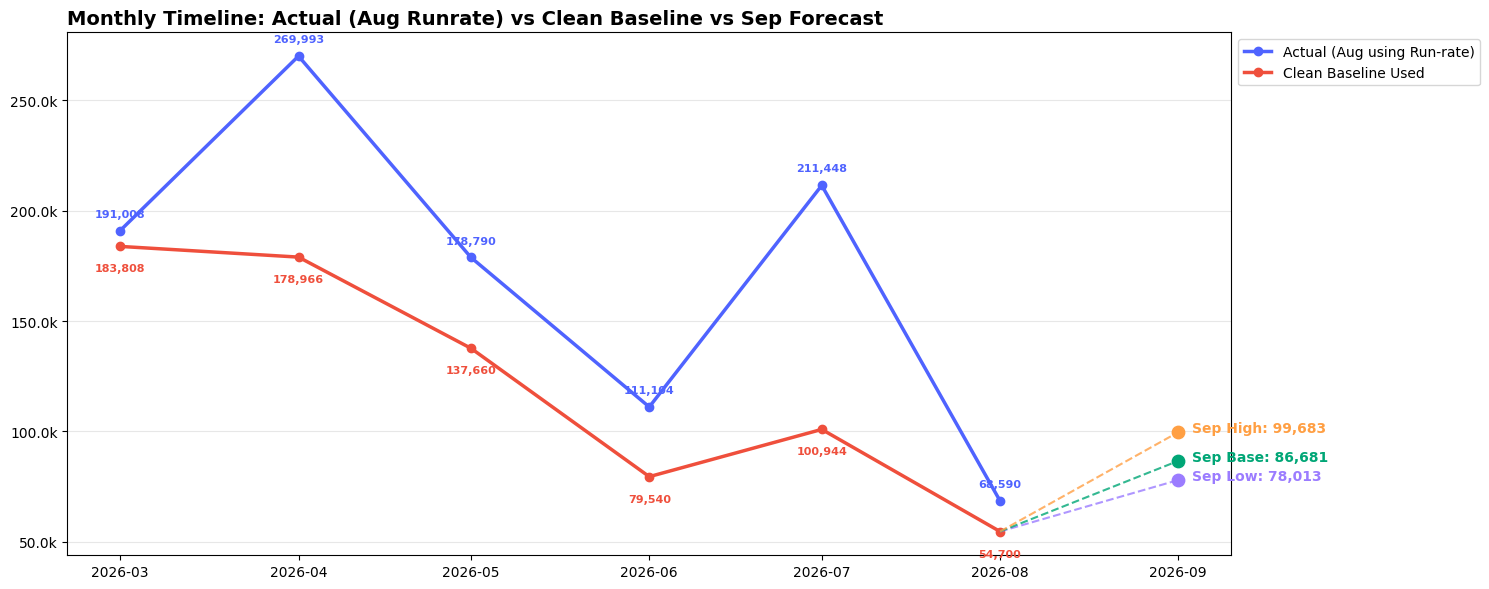

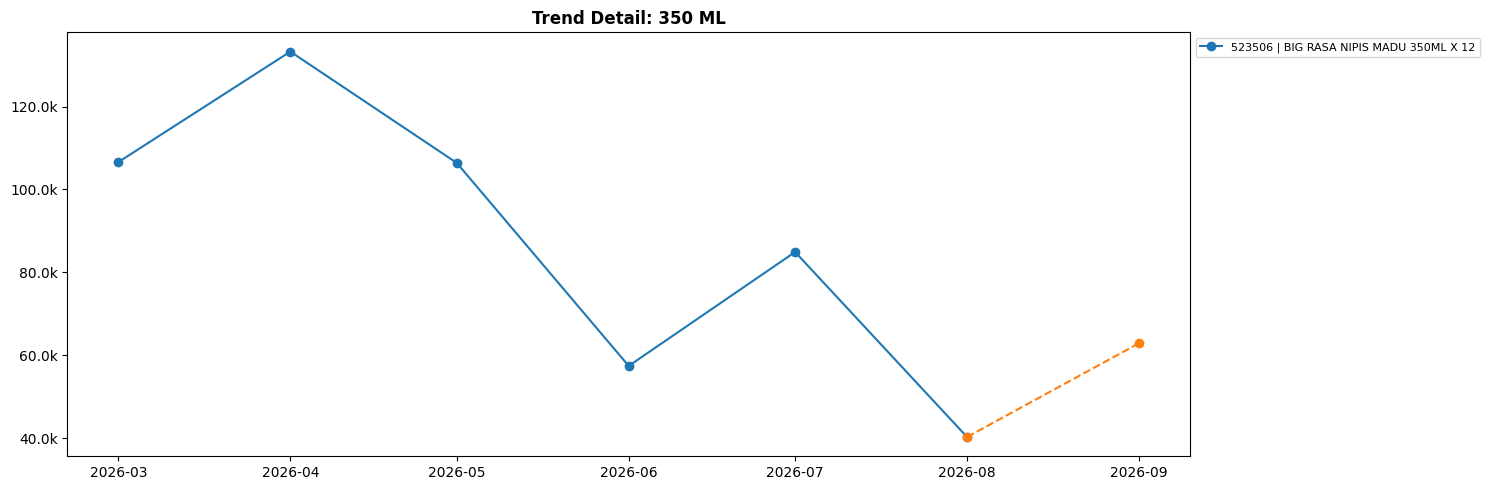

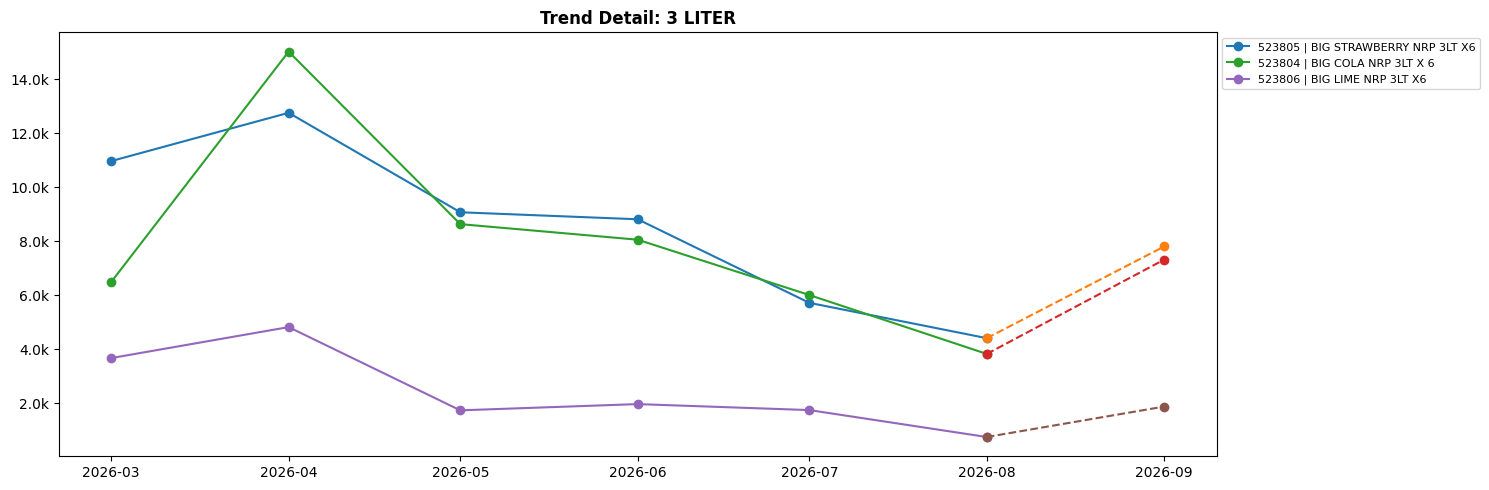

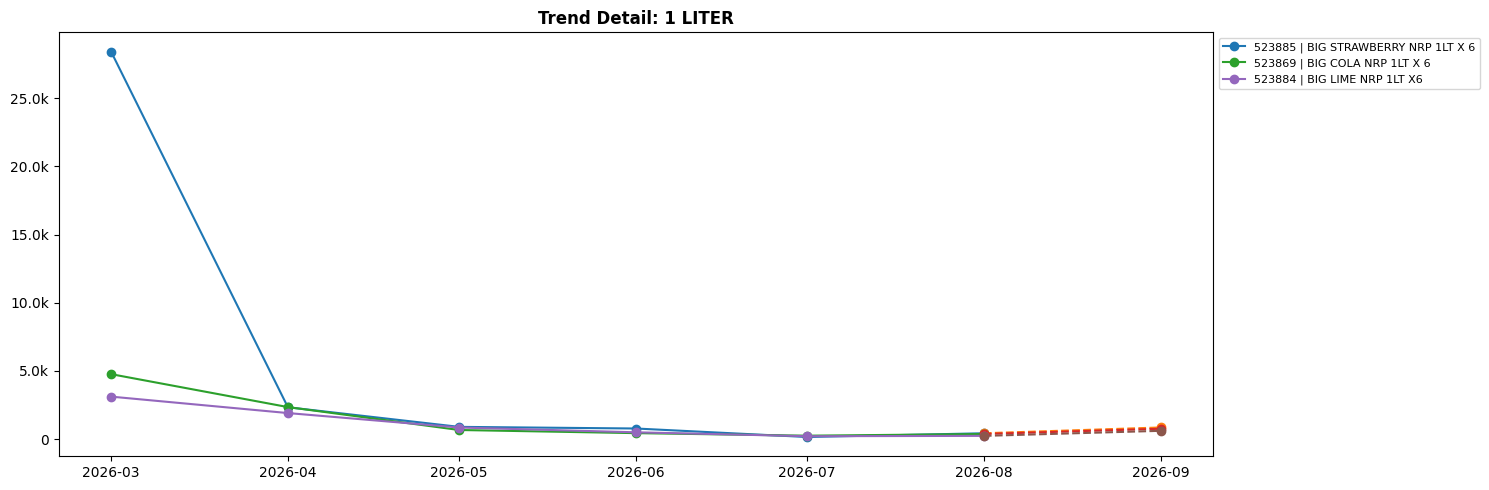

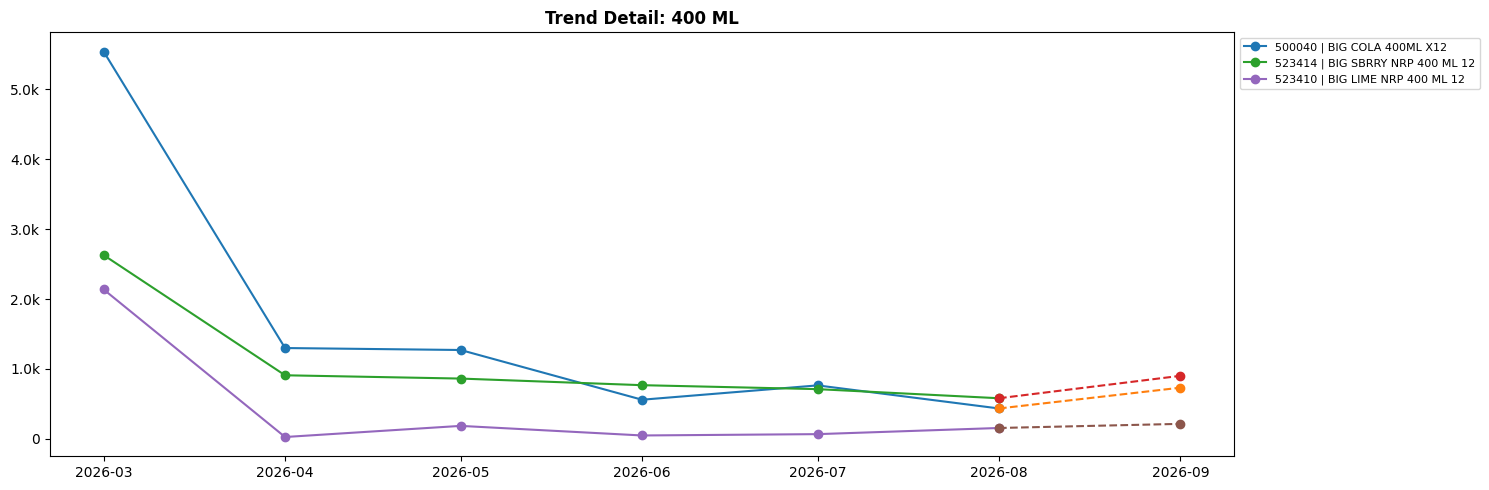

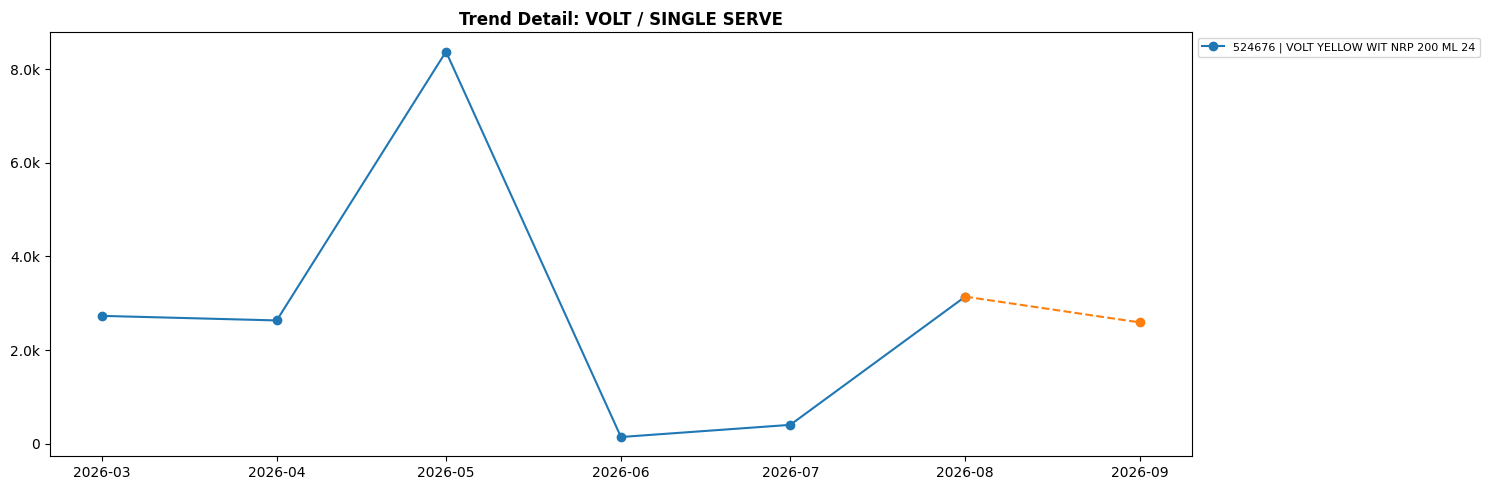

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==========================================
# 22. 21. MONTHLY FORECAST CHART
# ==========================================

# 1. PREPARASI DATA TOTAL
aug_runrate_total = forecast_detail_sep["Aug_RunRate"].sum()

# Data Actual: Gunakan Run-rate untuk Agustus di visualisasi
actual_process_viz = []
for month in forecast_input_months:
    mon = month.strftime("%b")
    val = forecast_detail_sep[f"{mon}_Actual"].sum()
    if month == RUNRATE_MONTH:
        val = aug_runrate_total
    actual_process_viz.append({"Month_Date": month, "Metric": "Actual (Aug=Runrate)", "CF": val})
actual_total = pd.DataFrame(actual_process_viz)

# Data Baseline
baseline_total = []
for month in forecast_input_months:
    mon = month.strftime("%b")
    baseline_total.append({"Month_Date": month, "Metric": "Clean Baseline Used", "CF": forecast_detail_sep[f"{mon}_Clean"].sum()})
baseline_total = pd.DataFrame(baseline_total)

# Forecast Points
sep_low = forecast_detail_sep["Sep Forecast Low"].sum()
sep_base = forecast_detail_sep["Sep Forecast Base"].sum()
sep_high = forecast_detail_sep["Sep Forecast High"].sum()

def fmt_k(value, _pos=None):
    if abs(value) >= 1000: return f"{value / 1000:.1f}k"
    return f"{value:.0f}"

def label_series(ax, df, color, dy=8):
    for _, row in df.iterrows():
        ax.annotate(f"{row['CF']:,.0f}", (row['Month_Date'], row['CF']), xytext=(0, dy), textcoords="offset points", ha='center', fontsize=8, color=color, fontweight='bold')

if plt is not None:
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(actual_total["Month_Date"], actual_total["CF"], marker="o", linewidth=2.5, color="#4f63ff", label="Actual (Aug using Run-rate)")
    ax.plot(baseline_total["Month_Date"], baseline_total["CF"], marker="o", linewidth=2.5, color="#ef4f3c", label="Clean Baseline Used")

    label_series(ax, actual_total, "#4f63ff", dy=10)
    label_series(ax, baseline_total, "#ef4f3c", dy=-18)

    aug_anchor = baseline_total.loc[baseline_total["Month_Date"] == RUNRATE_MONTH, "CF"].values[0]
    for val, col, lab in zip([sep_low, sep_base, sep_high], ["#9b7cff", "#00a676", "#ff9f43"], ["Low", "Base", "High"]):
        ax.plot([RUNRATE_MONTH, FORECAST_MONTH], [aug_anchor, val], linestyle="--", color=col, alpha=0.8)
        ax.scatter([FORECAST_MONTH], [val], color=col, s=80, zorder=5)
        ax.annotate(f"Sep {lab}: {val:,.0f}", (FORECAST_MONTH, val), xytext=(10, 0), textcoords="offset points", color=col, fontweight='bold')

    ax.set_title("Monthly Timeline: Actual (Aug Runrate) vs Clean Baseline vs Sep Forecast", fontsize=14, fontweight='bold', loc='left')
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_k))
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# 2. PACK GROUP BREAKDOWN CHARTS
def pack_group_from_sku(sku):
    sku = str(sku).upper()
    if "VOLT" in sku: return "VOLT / SINGLE SERVE"
    if "350ML" in sku or "350 ML" in sku: return "350 ML"
    if "400ML" in sku or "400 ML" in sku: return "400 ML"
    if "3LT" in sku or "3L" in sku: return "3 LITER"
    if "1LT" in sku or "1 LT" in sku: return "1 LITER"
    return "OTHER"

group_rows = []
for sku, sku_rows in forecast_detail_sep.groupby("SKU Edit"):
    group = pack_group_from_sku(sku)
    sep_val = float(sku_rows["Sep Forecast Base"].sum())
    for month in forecast_input_months:
        mon = month.strftime("%b")
        val = float(sku_rows[f"{mon}_Clean"].sum())
        group_rows.append({"Pack Group": group, "SKU Edit": sku, "Month_Date": month, "CF": val, "Type": "History"})
    group_rows.append({"Pack Group": group, "SKU Edit": sku, "Month_Date": FORECAST_MONTH, "CF": sep_val, "Type": "Forecast"})

df_groups = pd.DataFrame(group_rows)
groups_to_show = df_groups.groupby("Pack Group")["CF"].sum().nlargest(6).index

for grp in [g for g in groups_to_show if g != 'OTHER']:
    grp_data = df_groups[df_groups["Pack Group"] == grp]
    top_skus = grp_data.groupby("SKU Edit")["CF"].sum().nlargest(5).index

    fig, ax = plt.subplots(figsize=(15, 5))
    for sku in top_skus:
        s_data = grp_data[grp_data["SKU Edit"] == sku].sort_values("Month_Date")
        ax.plot(s_data[s_data["Type"]=="History"]["Month_Date"], s_data[s_data["Type"]=="History"]["CF"], marker="o", label=sku)
        ax.plot(s_data["Month_Date"].tail(2), s_data["CF"].tail(2), linestyle="--", marker="o")

    ax.set_title(f"Trend Detail: {grp}", fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_k))
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    plt.tight_layout()
    plt.show()

## 22. Export Forecast CSV

File CSV akan disimpan di folder `forecast_output` pada folder yang sama dengan file dashboard di Google Drive.

In [207]:
# ==========================================
# 23. 22. EXPORT FORECAST CSV (3 FILES - FULL MATRIX)
# ==========================================
# Menyimpan hasil forecast ke 3 file CSV dengan basis matrix lengkap Customer x SKU.

EXPORT_DIR = DRIVE_SALES_FILE.parent / "forecast_output"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
forecast_label = FORECAST_MONTH.strftime("%Y_%m")

# 1. PREPARASI DATA TRANSAKSI (FILE 01)
order_clean_adjusted = forecast_source[[
    "Source Sheet", "Year", "Month No", "Date",
    "Channel Group", "Original Customer Name", "Customer Name", "Original Branch", "Branch", "Channel", "Cust Code",
    "Short Item Description Real", "Item Code Real",
    "Short Item Description Edit", "Item Code Edit",
    "Format", "Box Content", "Reference Format", "Reference Box Content",
    "CF Real", "CF Edit", "CF Adjustment",
    "Group Key", "SKU Real", "SKU Edit", "Real != Edit",
]].copy()

# 2. MEMBUAT SKELETON FULL MATRIX (CROSS JOIN)
cust_list = forecast_source[['Cust Code', 'Customer Name', 'Branch', 'Channel Group']].drop_duplicates('Cust Code')
sku_list = forecast_source[['Item Code Edit', 'Short Item Description Edit', 'SKU Edit']].drop_duplicates('SKU Edit')
skeleton = cust_list.assign(key=1).merge(sku_list.assign(key=1), on='key').drop('key', axis=1)

# 3. PIVOT DATA AKTUAL 2026
export_months = pd.date_range("2026-01-01", "2026-12-01", freq="MS")
export_month_labels = [m.strftime("%b_Actual") for m in export_months]

actual_2026_pivot = (
    monthly_customer_sku[monthly_customer_sku["Month"].dt.year.eq(2026)]
    .pivot_table(index=key_cols, columns="Month", values="CF", aggfunc="sum", fill_value=0)
    .reset_index()
)

for month in export_months:
    if month not in actual_2026_pivot.columns:
        actual_2026_pivot[month] = 0

actual_2026_pivot = actual_2026_pivot[key_cols + list(export_months)].rename(
    columns={month: label for month, label in zip(export_months, export_month_labels)}
)

# 4. GABUNGKAN SKELETON DENGAN DATA FORECAST & PIVOT
forecast_calc_cols = [
    "Mar_Clean", "Apr_Clean", "May_Clean", "Jun_Clean", "Aug_Clean",
    "Aug_MTD", "Aug_RunRate", "Aug_Clean_RunRate",
    "Promo_Suspect_Months", "Promo_Suspect_Uplift",
    "Active Months", "Inactive 3M Rule", "Volatility", "Demand Class",
    "Sep Forecast Base", "Sep Forecast Low", "Sep Forecast High",
    "UC_Factor", "Sep Forecast Base UC"
]

# Gabungkan skeleton ke data detail forecast & pivot aktual
full_matrix_data = skeleton.merge(forecast_detail_sep[key_cols + forecast_calc_cols], on=key_cols, how='left')
full_matrix_data = full_matrix_data.merge(actual_2026_pivot[key_cols + export_month_labels], on=key_cols, how='left')

# Penanganan Null untuk Full Matrix
full_matrix_data['Demand Class'] = full_matrix_data['Demand Class'].fillna("No History")
full_matrix_data[export_month_labels] = full_matrix_data[export_month_labels].fillna(0)
numeric_cols = [c for c in full_matrix_data.columns if 'Forecast' in c or 'Clean' in c or 'Uplift' in c or 'UC' in c]
full_matrix_data[numeric_cols] = full_matrix_data[numeric_cols].fillna(0)

# 5. PEMBAGIAN FILE EKSPOR
# File 02: Matrix Bulanan + Forecast Kalkulasi (Full Matrix)
pivot_full_export = full_matrix_data[key_cols + export_month_labels + forecast_calc_cols].copy()

# File 03: Ringkasan Forecast Sept (Full Matrix)
forecast_sep_full = full_matrix_data[[
    "Channel Group", "Branch", "Cust Code", "Customer Name",
    "Item Code Edit", "Short Item Description Edit", "SKU Edit",
    "Demand Class", "Inactive 3M Rule", "UC_Factor",
    "Sep Forecast Low", "Sep Forecast Base", "Sep Forecast High",
    "Sep Forecast Base UC"
]].copy()
forecast_sep_full.insert(0, "Forecast Month", FORECAST_MONTH.strftime("%Y-%m"))

export_files = {
    f"01_order_clean_adjusted_{forecast_label}_modern.csv": order_clean_adjusted,
    f"02_pivot_customer_sku_full_matrix_{forecast_label}_modern.csv": pivot_full_export,
    f"03_forecast_sep_full_matrix_{forecast_label}_modern.csv": forecast_sep_full,
}

# Menulis file ke Drive
exported_paths = []
for filename, dataframe in export_files.items():
    output_path = EXPORT_DIR / filename
    dataframe.to_csv(output_path, index=False, encoding="utf-8-sig")
    exported_paths.append(str(output_path))

print("Export folder:", EXPORT_DIR)
print(f"Rows in Full Matrix: {len(full_matrix_data)}")
print("Exported CSV files:")
for path in exported_paths:
    print("-", path)

Exported Full Matrix: 4386 rows
File saved to: /content/drive/MyDrive/Data Sales/forecast_output/02_FULL_matrix_customer_sku_forecast_2026_09_modern.csv


### Audit Khusus: Bali & Pekanbaru
Sel ini bertujuan untuk melacak apakah volume historis dari area Bali dan Pekanbaru tertangkap dalam perhitungan, meskipun ada perubahan nama branch.

In [208]:
# Mengecek list customer yang memiliki transaksi di branch dengan kata kunci BALI atau PEKANBARU
area_keywords = ['BALI', 'PEKANBARU']

# Cari di data original sales_aligned_append
area_audit = sales_aligned_append[
    sales_aligned_append['Branch'].str.contains('|'.join(area_keywords), case=False, na=False) |
    sales_aligned_append['Customer Name'].str.contains('|'.join(area_keywords), case=False, na=False)
].copy()

# Ringkasan volume per Branch dan Bulan untuk area ini
area_summary = area_audit.groupby(['Branch', 'Month']).agg(CF=('CF Edit', 'sum')).reset_index()
area_summary = area_summary.pivot(index='Branch', columns='Month', values='CF').fillna(0)

print("Ringkasan Volume di Branch terkait Bali/Pekanbaru:")
display(area_summary)

# Cek apakah customer di area ini masuk ke tabel Forecast atau tereliminasi
area_cust_codes = area_audit['Cust Code'].unique()
area_forecast_check = forecast_detail_sep[forecast_detail_sep['Cust Code'].isin(area_cust_codes)]

print(f"\nJumlah Customer Area Audit di tabel Forecast: {len(area_forecast_check)} dari total {len(area_cust_codes)} customer")
display(area_forecast_check[['Branch', 'Cust Code', 'Customer Name', 'Demand Class', 'Sep Forecast Base']].head(20))

Ringkasan Volume di Branch terkait Bali/Pekanbaru:


Month,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
Branch,,,,,,,,,,,,,,,,,,,,
CEDIS MT SURABAYA,550.0,831.0,200.0,1279.0,438.0,247.0,3063.0,654.0,2868.0,2583.0,2530.0,3569.0,751.0,274.0,272.0,1607.0,3801.0,4067.0,0.0,0.0
FACTORY,3882.0,997.0,3350.0,722.0,-3.0,2102.0,8441.0,16433.0,18226.0,19015.0,3027.0,32912.0,2877.0,7555.5,13734.0,12896.0,9806.5,7656.0,3966.0,0.0
LOGISTIC PROVIDER BALI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9047.0,1518.0
LOGISTIC PROVIDER BEKASI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0
LOGISTIC PROVIDER PEKANBARU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,170.0,554.0,380.0,0.0,0.0,0.0,348.0,2613.0



Jumlah Customer Area Audit di tabel Forecast: 51 dari total 15 customer


,Branch,Cust Code,Customer Name,Demand Class,Sep Forecast Base
1930,LOGISTIC PROVIDER PEKANBARU,155537,PT.SUMBER ALFARIA TRIJAYA_PEKANBARU ...,Stable,3523.500
773,LOGISTIC PROVIDER BALI,153735,PT.SUMBER ALFARIA TRIJAYA_LOMBOK ...,Intermittent,3000.000
764,LOGISTIC PROVIDER BALI,126142,PT.SUMBER ALFARIA TRIJAYA_BALI ...,Stable,2475.000
1927,LOGISTIC PROVIDER PEKANBARU,151846,PT. INDOMARCO PRISMATAMA PEKANBARU ...,Stable,595.875
770,LOGISTIC PROVIDER BALI,137384,PT. INDOMARCO PRISMATAMA_BALI ...,Stable,354.750
1929,LOGISTIC PROVIDER PEKANBARU,151846,PT. INDOMARCO PRISMATAMA PEKANBARU ...,Stable,262.875
1936,LOGISTIC PROVIDER PEKANBARU,161445,PT.INTI CAKRAWALA CITRA_PEKANBARU ...,Stable,240.000
1928,LOGISTIC PROVIDER PEKANBARU,151846,PT. INDOMARCO PRISMATAMA PEKANBARU ...,Stable,196.625
771,LOGISTIC PROVIDER BALI,137384,PT. INDOMARCO PRISMATAMA_BALI ...,Stable,168.500
772,LOGISTIC PROVIDER BALI,137384,PT. INDOMARCO PRISMATAMA_BALI ...,Intermittent,161.000


### Perbaikan Pemetaan Branch (Bali & Pekanbaru)
Sel ini melakukan override manual untuk memastikan semua customer yang teridentifikasi sebagai area ekspansi dipetakan ke branch baru, sehingga volume historis mereka tidak hilang atau salah kamar di branch lama.

In [57]:
import numpy as np

# 1. Definisikan mapping manual untuk customer area ekspansi berdasarkan kata kunci
# Kita ambil Cust Code yang pernah bertransaksi di branch Bali/Pekanbaru
bali_cust = area_audit[area_audit['Branch'].str.contains('BALI', case=False, na=False)]['Cust Code'].unique()
pku_cust = area_audit[area_audit['Branch'].str.contains('PEKANBARU', case=False, na=False)]['Cust Code'].unique()

# 2. Update Branch di tabel forecast_detail_sep
forecast_detail_sep.loc[forecast_detail_sep['Cust Code'].isin(bali_cust), 'Branch'] = 'LOGISTIC PROVIDER BALI'
forecast_detail_sep.loc[forecast_detail_sep['Cust Code'].isin(pku_cust), 'Branch'] = 'LOGISTIC PROVIDER PEKANBARU'

# 3. Verifikasi hasil setelah perpindahan
print("Ringkasan Forecast September Setelah Re-mapping Branch:")
branch_recap = forecast_detail_sep[forecast_detail_sep['Branch'].isin(['LOGISTIC PROVIDER BALI', 'LOGISTIC PROVIDER PEKANBARU'])] \
    .groupby('Branch') \
    .agg(Total_Cust=('Cust Code', 'nunique'),
         Total_Forecast_CF=('Sep Forecast Base', 'sum'),
         Total_Forecast_UC=('Sep Forecast Base UC', 'sum'))

display(branch_recap)

# Cek apakah masih ada volume area Bali/PKU yang 'tertinggal' di branch lain
residual_check = area_audit[~area_audit['Cust Code'].isin(list(bali_cust) + list(pku_cust))]
if not residual_check.empty:
    print("\nWarning: Ada customer area Bali/PKU yang belum terpetakan:")
    display(residual_check[['Cust Code', 'Customer Name', 'Branch']].drop_duplicates())

Ringkasan Forecast September Setelah Re-mapping Branch:


,Total_Cust,Total_Forecast_CF,Total_Forecast_UC
Branch,,,
LOGISTIC PROVIDER BALI,4,6490.250,1108.5050
LOGISTIC PROVIDER PEKANBARU,3,4818.875,886.0125


,Cust Code,Customer Name,Branch
139,68820,BALIGE ...,FACTORY
501,417004,PT.SAUDARA RIAU ABADI_PEKANBARU ...,FACTORY
706,187919,PT. LOTTE SHOPPING INDONESIA_BALIKPAPAN ...,FACTORY
1547,187917,PT. LOTTE SHOPPING INDONESIA BALI ...,CEDIS MT SURABAYA
4079,187914,PT. LOTTE SHOPPING INDONESIA_PEKANBARU ...,FACTORY
4554,417281,CIRCLE K_BALI ...,CEDIS MT SURABAYA
9633,417433,DHANA DISTRIBUSI_KARANGASEM BALI ...,CEDIS MT SURABAYA
33184,418519,CAHAYA GLOBALINDO EXPRESS ...,LOGISTIC PROVIDER BEKASI


In [59]:
# 1. Identifikasi customer Bali & Pekanbaru dari transaksi 2026
area_2026 = sales_aligned_append[
    (sales_aligned_append['Year'] >= 2026) &
    (sales_aligned_append['Branch'].str.contains('BALI|PEKANBARU', case=False, na=False))
].copy()

bali_cust_2026 = area_2026[area_2026['Branch'].str.contains('BALI', case=False, na=False)]['Cust Code'].unique()
pku_cust_2026 = area_2026[area_2026['Branch'].str.contains('PEKANBARU', case=False, na=False)]['Cust Code'].unique()

print(f"Customer terdeteksi di Bali (2026): {len(bali_cust_2026)}")
print(f"Customer terdeteksi di Pekanbaru (2026): {len(pku_cust_2026)}")

# 2. Lakukan override branch di forecast_source (dataset MODERN)
# Ini memastikan semua volume history (Jan-Aug) dari Surabaya/Factory ditarik ke branch baru
forecast_source.loc[forecast_source['Cust Code'].isin(bali_cust_2026), 'Branch'] = 'LOGISTIC PROVIDER BALI'
forecast_source.loc[forecast_source['Cust Code'].isin(pku_cust_2026), 'Branch'] = 'LOGISTIC PROVIDER PEKANBARU'

# 3. Hitung ulang grain bulanan setelah re-mapping agar forecast akurat
daily_customer_sku_new = forecast_source.groupby(['Date', 'Month', *key_cols], as_index=False).agg(CF=('CF Edit', 'sum'))
monthly_customer_sku = daily_customer_sku_new.groupby(['Month', *key_cols], as_index=False).agg(CF=('CF', 'sum'))

print("\nRe-mapping Branch Selesai. Data bulanan telah diperbarui.")

Customer terdeteksi di Bali (2026): 4
Customer terdeteksi di Pekanbaru (2026): 3

Re-mapping Branch Selesai. Data bulanan telah diperbarui.
